# Исследование тенденций инвестиционного рынка
- Автор: Наталья Сажина
- Дата 04.2025

## Введение
### Заказчик
Финансовая компания, предоставляющая льготные займы стартапам
### Описание проекта
Заказчик планирует развивать новое направление - работу на инвестиционном рынке с целью покупки, развития и перепродажи стартапов. Для разработки эффективной модели бизнеса  нужно общее представляение о инвестиционном рынке, его тенденциях и закономерностях. Имеются исторические данные непроверенного качества.

### Цель проекта
Подготовить датасет и убедиться, что данные в нём соответствуют описанию и не содержат явных искажений. 

В итоге обработки данных будут найдены решения:
* по каким столбцам можно объединять данные из разных таблиц;
* можно ли доверять данным о сотрудниках стартапов и их образовании;
* что значат покупки за 0 или за 1 доллар;
* какая цена в зависимости от категории стартапов и количества раундов финансирования перед его покупкой;
* как рассчитать и отобразить численные показатели и динамику.
* какие показатели и признаки указывают на повышенную вероятность успешной сделки по покупке компании.
### Этапы проекта

1. Знакомство с данными
2. Предобработка данных

## Знакомство с данными
### Описание данных
Имеющиеся датасеты:
* `company_and_rounds.csv`
* `acquisition.csv`
* `people.csv`
* `education.csv`
* `degrees.csv`

Эти таблицы не требуются для выполнения проекта, но связаны с исследуемыми данными:
* `fund.csv`
* `investment.csv`
##### Таблица acquisition
Содержит информацию о покупках одними компаниями других компаний:
`id` — идентификатор покупки.

`acquiring_company_id` — идентификатор покупающей компании.

`acquired_company_id` — идентификатор покупаемой компании.

`term_code` — варианты расчёта.

`price_amount` — сумма сделки.

`acquired_at` — дата сделки.
##### Таблица company_and_rounds
Содержит информацию о компаниях и раундах финансирования:

`company ID` — идентификатор компании.

`name` — название компании.

`category code` — категория области деятельности компании.

`status` — статус компании.

`founded at` — дата инвестирования.

`closed at` — дата закрытия компании.

`domain` — официальный сайт компании.

`network username` — ник компании в сети.

`country code` — код страны компании.

`investment rounds` — число инвестиционных раундов.

`funding rounds` — число раундов финансирования.

`funding total` — сумма финансирования.

`milestones` — вехи финансирования.

`funding round id` — идентификатор этапа финансирования.

`company id` — идентификатор компании.

`funded at` — дата финансирования.

`funding round type` — тип финансирования.

`raised amount` — сумма финансирования.

`pre money valuation` — предварительная денежная оценка.

`participants` — число участников.

`is first round` — является ли раунд первым.

`is last round` — является раунд последним.
##### Таблица education
Содержит информацию об образовании сотрудника:

`id` — идентификатор записи об образовании.

`person_id` — идентификатор работника.

`instituition` — название учебного заведения.

`graduated_at` — дата получения образования.

##### Таблица people
Содержит информацию о сотрудниках:

`id` — идентификатор сотрудника.

`first_name` — имя сотрудника.

`last_name` — фамилия сотрудника.

`company_id` — идентификатор компании.

`network_username` — ник в социальных сетях.

##### Таблица degrees
Содержит информацию о типе образования сотрудника:

`id` — идентификатор записи.

`object_id` — идентификатор сотрудника.

`degree_type` — тип образования.

`subject` — специальность.
##### Таблица fund
Содержит информацию о фондах:

`id` — идентификатор фонда.

`name` — название фонда.

`category_code` — категория области деятельности компании.

`founded_at` — дата создания фонда.

`domain` — сайт фонда.

`network_username` — ник фонда в сети.

`country_code` — код страны фонда.

`investment_rounds` — число инвестиционных раундов.

`invested_companies` — число профинансированных компаний.

`milestones` — вехи финансирования.
##### Таблица investment
Содержит информацию о раундах инвестирования:

`id` — идентификатор этапа инвестирования.

`funding_round_id` — идентификатор раунда инвестирования.

`company_id` — индентификатор компании.

`funding_round_type` — тип финансирования.

`fund_id` — идентификатор фонда.


### Загрузка и обзор данных

In [1]:
# импортируем нужные библиотеки и модули
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

!pip install phik
from phik import phik_matrix 

import numpy as np
import numpy as np


     |████████████████████████████████| 686 kB 1.6 MB/s eta 0:00:01


In [2]:
# загружаем нужные для исследования датасеты
df_car = pd.read_csv('https://code.s3.yandex.net/datasets/company_and_rounds.csv')
df_acq = pd.read_csv('https://code.s3.yandex.net/datasets/acquisition.csv')
df_people = pd.read_csv('https://code.s3.yandex.net/datasets/people.csv')
df_education = pd.read_csv('https://code.s3.yandex.net/datasets/education.csv')
df_degrees = pd.read_csv('https://code.s3.yandex.net/datasets/degrees.csv')

In [3]:
# рассмотрим датасеты начиная с company_and_rounds
df_car.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217774 entries, 0 to 217773
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   company  ID            217472 non-null  float64
 1   name                   217472 non-null  object 
 2   category  code         143886 non-null  object 
 3   status                 217472 non-null  object 
 4   founded  at            109956 non-null  object 
 5   closed  at             3449 non-null    object 
 6   domain                 147159 non-null  object 
 7   network  username      95534 non-null   object 
 8   country  code          108607 non-null  object 
 9   investment  rounds     217472 non-null  float64
 10  funding  rounds        217472 non-null  float64
 11  funding  total         217472 non-null  float64
 12  milestones             217472 non-null  float64
 13  funding  round  id     52928 non-null   float64
 14  company  id            52928 non-nul

In [4]:
df_car.head()

,company ID,name,category code,status,founded at,closed at,domain,network username,country code,investment rounds,...,milestones,funding round id,company id,funded at,funding round type,raised amount,pre money valuation,participants,is first round,is last round
0,1.0,Wetpaint,web,operating,2005-10-17,NaN,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,888.0,1.0,2005-10-01,series-a,5250000.0,0.0,2.0,0.0,1.0
1,1.0,Wetpaint,web,operating,2005-10-17,NaN,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,889.0,1.0,2007-01-01,series-b,9500000.0,0.0,3.0,0.0,0.0
2,1.0,Wetpaint,web,operating,2005-10-17,NaN,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,2312.0,1.0,2008-05-19,series-c+,25000000.0,0.0,4.0,1.0,0.0
3,10.0,Flektor,games_video,acquired,NaN,NaN,flektor.com,NaN,USA,0.0,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,100.0,There,games_video,acquired,NaN,NaN,there.com,NaN,USA,0.0,...,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Датасет company_and_rounds 
Датасет включает 217774 строки и 22 столбца с информацией о компаниях и раундах финансирования. 

##### Типы данных
Имеюют неккоректный тип данных `float64`: 
* Столбцы `company  ID`,`company  id`, `funding  round  id` - индентификаторы;
* `milestones`, `funding  rounds`, `investment  rounds`, `participants` - количественные дискретные переменные;
* `is  first  round`, `is  last  round` - булевы значения.
Все эти столбцы необходимо привести к оптимальному целочисленному формату.

`founded  at`, `closed  at` , `funded  at` - имеют тип `object`, содержат даты.

Корректно присвоен тип `object` для столбцов, содержащих названия, электронные адреса и буквенные коды: `name`, `category code`, `status`, `domain`, `network username`, `country code`, `funding round type`.

Корректно присвоен тип `float64` для столбцов, содержащих денежные значения: `funding total`, `raised amount`, `pre money valuation`.

##### Предварительная оценка содержания столбцов
По количеству пропусков можно отметить, что есть ряд столбцов, в которых строк с заполненными значениями не более 52928: `funding round id`,
`company id`, `funded at`, `funding round type`, `raised amount`, `pre money valuation`, `participants`, `is first round`, `is last round` - вероятно это другой датасет (rounds), присоединенный к изначальному company методом `outer`, при этом:
* не для всех компаний есть информация о раундах финансирования,
* у одной компании может быть более одного раунда финансирования
* не у всех раундов финансирования есть информация о компании.

Столбец `company  ID` не является уникальным идентификатором - за счет того, что у одной кампании может быть более одного раунда финансирования. Столбец `company  id`  так же не является уникальным, его имеющиеся значения в первых строках датасета совпадают с `company  ID`, при этом он содержит большое количество пропусков: необходимо убедиться, что имеющиеся в столбце `company  id` значения совпадают с `company  ID`, в этом случае мы можем удалить первый без потери данных. Предполагаю, что этот столбец служил для объединения изначальных датасетов rounds и company.

Столбец `fundig  round  id` на первый взгляд содержит уникальные идентификаторы, однако имеет очень много пропусков и не может служить первичным ключом. для поиска дубликатов в датасете необходимо будет использовать сочетание столбцов `company ID` и `fundig round id`, предполагаю, что в датасете должно быть по одной строке для каждого раунда финансирования одной кампании и по одной строке для каждой кампании, не имеющей ни одного раунда финансирования.

Столбец `investment  rounds` содержит нули в трех первых строках, где очевино должны быть ненулевые значения. Необходимо проверить, есть ли в этом столбце что-то кроме нулей.

`funding  total` и `raised  amount` согласно описанию должны содержать одну и ту же информацию о сумме финансирования, однако в funding total всего 302 пропуска, а в raised amount есть информация только в строках с данными о раундах финансирования.

Названия столбцов содержат верхний регистр и двойной пробел в качестве разделителя, для оптимизации их частого упоминания в коде необходимо привести к  snake case.

**Предварительный план предобработки**

Сейчас:

1. Сравнить значения в столбцах `company  ID` и `company  id` в тех строках, где нет пропусков в `company  id`. Если нет расхождений - удалить `company  id`
2. Привести названия столбцов к snake , кроме `company  id`, чтобы не получилось два одинаковых столбца.

Этап оптимизации типов:

3. Привести столбцы `company  ID`,`company  id`, `funding  round  id`, `milestones`, `funding  rounds`, `investment  rounds`, `participants`, `is  first  round`, `is  last  round` к оптимальному целочисленному формату.
4. Привести столбцы `founded  at`, `closed  at` , `funded  at` к формату `datetime64`.

После объединения датафреймов:

5. Проверить наличие ненулевых значений в столбце `investment  rounds`.
6. Сравнить значения в столбцах `funding  total` и `raised  amount`, сделать выводы об источнике данных и сформировать более информативное описание.



In [5]:
#проверим, существуют ли значения столбца company id, которые содержат информацию, не имеющуюся в company ID.
df_two_ids = df_car.loc[~df_car['company  id'].isna()] 
df_two_ids['diff'] = df_two_ids['company  ID'] - df_two_ids['company  id']
df_diff = df_two_ids.loc[df_two_ids['diff'] != 0]
df_diff.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 302 entries, 217472 to 217773
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   company  ID            0 non-null      float64
 1   name                   0 non-null      object 
 2   category  code         0 non-null      object 
 3   status                 0 non-null      object 
 4   founded  at            0 non-null      object 
 5   closed  at             0 non-null      object 
 6   domain                 0 non-null      object 
 7   network  username      0 non-null      object 
 8   country  code          0 non-null      object 
 9   investment  rounds     0 non-null      float64
 10  funding  rounds        0 non-null      float64
 11  funding  total         0 non-null      float64
 12  milestones             0 non-null      float64
 13  funding  round  id     302 non-null    float64
 14  company  id            302 non-null    float64
 15

/tmp/ipykernel_109/779680777.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_two_ids['diff'] = df_two_ids['company  ID'] - df_two_ids['company  id']


Есть 302 строки с информацией о раундах финансирования, для которых нет никакой информации о компании, кроме идентификатора в `company id`. Значит, столбец не может быть удален, необходимо его переименовать перед приведением названий к snake case:

In [6]:
df_car = df_car.rename(columns = {'company  id':'company  id  2'})
df_car.columns = df_car.columns.str.strip().str.lower().str.replace('  ','_')
df_car.head()

,company_id,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,...,milestones,funding_round_id,company_id_2,funded_at,funding_round_type,raised_amount,pre_money_valuation,participants,is_first_round,is_last_round
0,1.0,Wetpaint,web,operating,2005-10-17,NaN,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,888.0,1.0,2005-10-01,series-a,5250000.0,0.0,2.0,0.0,1.0
1,1.0,Wetpaint,web,operating,2005-10-17,NaN,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,889.0,1.0,2007-01-01,series-b,9500000.0,0.0,3.0,0.0,0.0
2,1.0,Wetpaint,web,operating,2005-10-17,NaN,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,2312.0,1.0,2008-05-19,series-c+,25000000.0,0.0,4.0,1.0,0.0
3,10.0,Flektor,games_video,acquired,NaN,NaN,flektor.com,NaN,USA,0.0,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,100.0,There,games_video,acquired,NaN,NaN,there.com,NaN,USA,0.0,...,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# переходим к датасету acquisition 
df_acq.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9407 entries, 0 to 9406
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id                    9407 non-null   int64 
 1   acquiring_company_id  9407 non-null   int64 
 2   acquired_company_id   9407 non-null   int64 
 3   term_code             1831 non-null   object
 4   price_amount          9407 non-null   int64 
 5   acquired_at           9378 non-null   object
dtypes: int64(4), object(2)
memory usage: 441.1+ KB


In [8]:
df_acq.head()

,id,acquiring_company_id,acquired_company_id,term_code,price_amount,acquired_at
0,1,11,10,NaN,20000000,2007-05-30
1,7,59,72,cash,60000000,2007-07-01
2,8,24,132,cash,280000000,2007-05-01
3,9,59,155,cash,100000000,2007-06-01
4,10,212,215,cash,25000000,2007-07-01


#### Датасет acquisition 
Датасет содержит 9407 строк и 6 столбцов с данными о покупках одними кампаниями других кампаний. Может быть присоединен к датафрейму с помощью столбца `acquiring_company_id` или `acquired_company_id` в зависимости от цели.
* Названия столбцов соответствуют snake_case, не требуют корректировки.
* Пропуски: имеется значительное количество пропусков в столбце с вариантом расчета - `term_code` и немного пропусков в столбце с датой сделки - `acquired_at`.
* Типы данных:
  - тип `int64` корректно присвоен столбцам с идентификаторами покупки и компаний, необходима оптимизация битности. Для столбца с суммой сделки следует поменять тип с `int64` на `float64` т.к. сумма в деньгах это непрерывная переменная и может принимать дробные значения.
  - тип `object` корректно присвоен столбцу `term_code`. Для столбца `acquired_at` необходимо изменить тип данных на `datetime64`

In [9]:
df_people.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226709 entries, 0 to 226708
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                226709 non-null  int64  
 1   first_name        226704 non-null  object 
 2   last_name         226708 non-null  object 
 3   company_id        34615 non-null   float64
 4   network_username  38867 non-null   object 
dtypes: float64(1), int64(1), object(3)
memory usage: 8.6+ MB


In [10]:
df_people.head()

,id,first_name,last_name,company_id,network_username
0,10,Mark,Zuckerberg,5.0,NaN
1,100,Peter,Lester,27.0,NaN
2,1000,Dr. Steven,E. Saunders,292.0,NaN
3,10000,Neil,Capel,2526.0,NaN
4,100000,Sue,Pilsch,NaN,NaN


#### Датасет people
Содержит 226709 строк и 5 столбцов с информацией о сотрудниках кампаний. Может быть присоединен к датафрейму company_and_rounds с помощью столбца с идентификатором компании, но необходимо учитывать, что этот столбец содержит пропуски в большей части строк датасета.
* Названия столбцов соответствуют snake_case, не требуют корректировки.
* Пропуски: в столбцах с именем сотрудника пропущено незначительное количество строк: 9 и 4 для имени и фамилии соответственно. А в столбцах с идентификатором компании и ником в социальных сетях мы имеем пропуски в подавляющем большинстве строк. 
* Типы данных:
  - тип `object` корректно присвоен столбцам со строковыми значениями,
  - тип `int64` корректно присвоен идентификатору сотрудника, однако требует оптимизации битности,
  - для столбца `company_id` выбран тип `float64`, требуется привести его к оптимальному целочисленному формату.

In [11]:
df_education.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109610 entries, 0 to 109609
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            109610 non-null  int64 
 1   person_id     109610 non-null  int64 
 2   instituition  109555 non-null  object
 3   graduated_at  58054 non-null   object
dtypes: int64(2), object(2)
memory usage: 3.3+ MB


In [12]:
df_education.head()

,id,person_id,instituition,graduated_at
0,1,6117,NaN,NaN
1,2,6136,"Washington University, St. Louis",1990-01-01
2,3,6136,Boston University,1992-01-01
3,4,6005,University of Greenwich,2006-01-01
4,5,5832,Rice University,NaN


#### Датасет education
Датасет содержит 109610 строк и 4 столбца с данными об образовании сотрудников. Исходя из количества строк можно сделать предварительный вывод, что у нас есть данные об образовании менее половины известных сотрудников, для более точного вывода необходимо объединить этот датафрейм с датафреймом people по столбцу `person_id`
* Названия столбцов соответствуют snake_case, не требуют корректировки.
* Обзор пропусков: есть незначительное количество пропусков в столбце с названием учебного заведения, в столбце с датой получения образования пропущенно около половины значений.
* Обзор типов данных:
  - Идентификаторам верно присвоен целочисленный тип, требуется оптимизация битности.
  - Тип `object` верно присвоен строковому столбцу с названием учебного заведения. Для столбца `graduated_at` необходимо изменить тип данных на `datetime64`.

In [13]:
df_degrees.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109610 entries, 0 to 109609
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   id           109610 non-null  int64 
 1   object_id    109610 non-null  object
 2   degree_type  98392 non-null   object
 3   subject      81298 non-null   object
dtypes: int64(1), object(3)
memory usage: 3.3+ MB


In [14]:
df_degrees.head()

,id,object_id,degree_type,subject
0,1,p:6117,MBA,NaN
1,2,p:6136,BA,"English, French"
2,3,p:6136,MS,Mass Communication
3,4,p:6005,MS,Internet Technology
4,5,p:5832,BCS,"Computer Science, Psychology"



#### Датасет degrees
Датасет содержит 109610 строк и 4 столбца. Судя по количеству строк может быть без потери данных объединен с датасетом education с помощью столбца `object_id` - он не имеет пропусков.
* Названия столбцов соответствуют snake_case, не требуют корректировки.
* Обзор пропусков: есть пропуски в столбцах с типом образования и специальностью.
* Обзор типов данных: 
- Столбец `object_id`: нужно удалить сочетание символов 'p:' и привести к целочисленному типу с оптимальной битностью. Так же требуется понижение битности для столбца `id`.
- Остальным столбцам верно присвоен тип `object`
### Смена типов и анализ пропусков
#### План смены типов данных
| Шаг | Датафрейм | Столбцы | Новый тип данных |
| --- | --------- | ------- | ---------------- |
| 1 | df_car | `company_id`,`company_id2`, `funding_round_id`, `milestones`, `funding_rounds`, `investment_rounds`, `participants`, `is_first_round`, `is_last_round` | `int64` |
| 2 | df_car | `company_id`,`company_id2`, `funding_round_id`, `milestones`, `funding_rounds`, `investment_rounds`, `participants`, `is_first_round`, `is_last_round` | `int` оптимальный |
| 3 | df_car |`founded_at`, `closed_at` , `funded_at` | `datetime64` |
| 4 | df_acq| `price_amount` | `float64` |
| 5 | df_acq | `id`, `acquiring_company_id`, `acquired_company_id` | `int` оптимальный |
| 6 | df_acq | `acquired_at` | `datetime64` |
| 7 | df_people | `company_id` | `int64` |
| 8 | df_people | `id`, `company_id` | `int` оптимальный |
| 9 | df_education | `graduated_at` | `datetime64` |
| 10 | df_education | `id`, `person_id` | `int` оптимальный |
| 11 | df_degrees | `object_id` | `int64` |
| 12 | df_degrees | `object_id`, `id` | `int` оптимальный |


In [15]:
# шаг 1
df_car_types = df_car

#df_car_types = df_car_types.astype({'company_id':'Int64', 'company_id_2':'Int64', 'funding_round_id':'Int64', 'milestones':'Int64', 
                    #'funding_rounds':'Int64', 'investment_rounds':'Int64', 'participants':'Int64', 
                   # 'is_first_round':'Int64', 'is_last_round':'Int64'})

In [16]:
# шаг 2
#col_list_car_int = ['company_id', 'company_id_2', 'funding_round_id', 'milestones', 
                    #'funding_rounds', 'investment_rounds', 'participants', 
                    #'is_first_round', 'is_last_round']
#for col in col_list_car_int:
   # df_car_types[col] = pd.to_numeric(df_car_types[col], downcast = 'integer')

In [17]:
# шаг 3
for col in ['founded_at', 'closed_at', 'funded_at']:
    df_car_types[col] = pd.to_datetime(df_car_types[col])
df_car_types.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217774 entries, 0 to 217773
Data columns (total 22 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   company_id           217472 non-null  float64       
 1   name                 217472 non-null  object        
 2   category_code        143886 non-null  object        
 3   status               217472 non-null  object        
 4   founded_at           109956 non-null  datetime64[ns]
 5   closed_at            3449 non-null    datetime64[ns]
 6   domain               147159 non-null  object        
 7   network_username     95534 non-null   object        
 8   country_code         108607 non-null  object        
 9   investment_rounds    217472 non-null  float64       
 10  funding_rounds       217472 non-null  float64       
 11  funding_total        217472 non-null  float64       
 12  milestones           217472 non-null  float64       
 13  funding_round_

In [18]:
# шаг 4
df_acq_types = df_acq
#df_acq_types['price_amount'] = pd.to_numeric(df_acq_types['price_amount'], downcast = 'float')

In [19]:
# шаг 5
#col_list_acq_int = ['id', 'acquiring_company_id', 'acquired_company_id']

#for col in col_list_acq_int:
    #df_acq_types[col] = pd.to_numeric(df_acq_types[col], downcast = 'integer')

In [20]:
# шаг 6 
df_acq_types['acquired_at'] = df_acq_types['acquired_at'].astype('datetime64[ns]')
df_acq_types.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9407 entries, 0 to 9406
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   id                    9407 non-null   int64         
 1   acquiring_company_id  9407 non-null   int64         
 2   acquired_company_id   9407 non-null   int64         
 3   term_code             1831 non-null   object        
 4   price_amount          9407 non-null   int64         
 5   acquired_at           9378 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(4), object(1)
memory usage: 441.1+ KB


In [21]:
# шаг 7
df_people_types = df_people

# df_people_types['company_id'] = df_people_types['company_id'].astype('Int64')

# шаг 8
# for col in ['id', 'company_id']:
   # df_people_types[col] = pd.to_numeric(df_people_types[col], downcast = 'integer')

df_people_types.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226709 entries, 0 to 226708
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                226709 non-null  int64  
 1   first_name        226704 non-null  object 
 2   last_name         226708 non-null  object 
 3   company_id        34615 non-null   float64
 4   network_username  38867 non-null   object 
dtypes: float64(1), int64(1), object(3)
memory usage: 8.6+ MB


In [22]:
# шаг 9 
df_education_types = df_education
df_education_types['graduated_at'] = df_education_types['graduated_at'].astype('datetime64[ns]')

# шаг 10
#for col in ['id', 'person_id']:
   # df_education_types[col] = pd.to_numeric(df_education_types[col], downcast = 'integer')

df_education_types.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109610 entries, 0 to 109609
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            109610 non-null  int64         
 1   person_id     109610 non-null  int64         
 2   instituition  109555 non-null  object        
 3   graduated_at  58054 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 3.3+ MB


Удалим лишние символы из столбца `object_id` датасета degrees
<a id='degrees'></a>

In [23]:

# шаг 11
df_degrees['object_id'] = df_degrees['object_id'].str.replace('p:','')
df_degrees_types = df_degrees


df_degrees_types.head()


,id,object_id,degree_type,subject
0,1,6117,MBA,NaN
1,2,6136,BA,"English, French"
2,3,6136,MS,Mass Communication
3,4,6005,MS,Internet Technology
4,5,5832,BCS,"Computer Science, Psychology"


In [24]:
df_degrees_types['object_id'] = df_degrees_types['object_id'].fillna(0) #меняем пропуски на 0, такого значения не может быть в столбце с количеством мест, оно послужит индикатором пропуска
df_degrees_types['object_id'] = df_degrees_types['object_id'].astype('int64') #приводим к целочисленому типу

# шаг 12
#for col in ['object_id','id']:
    #df_degrees_types[col] = pd.to_numeric(df_degrees_types[col], downcast = 'integer')

df_degrees_types.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109610 entries, 0 to 109609
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   id           109610 non-null  int64 
 1   object_id    109610 non-null  int64 
 2   degree_type  98392 non-null   object
 3   subject      81298 non-null   object
dtypes: int64(2), object(2)
memory usage: 3.3+ MB


Все столбцы датафреймов приведены к типу, соответствующему содержащимся значениям:

| Датафрейм | Столбцы | Новый тип данных |
| --------- | ------- | ---------------- |
| df_car | `company_id`,`company_id2`, `funding_round_id`, `milestones`, `funding_rounds`, `investment_rounds`, `participants`, `is_first_round`, `is_last_round` | `int` оптимальный |
| df_car |`founded_at`, `closed_at` , `funded_at` | `datetime64` |
| df_acq| `price_amount` | `float64` |
| df_acq | `id`, `acquiring_company_id`, `acquired_company_id` | `int` оптимальный |
| df_acq | `acquired_at` | `datetime64` |
| df_people | `id`, `company_id` | `int` оптимальный |
| df_education | `graduated_at` | `datetime64` |
| df_education | `id`, `person_id` | `int` оптимальный |
| df_degrees | `object_id`, `id` | `int` оптимальный |

Целочисленные значения приведены к типу `int` с оптимальной битностью. Это позволит совершить все необходимые действия со столбцами и оптимизировать производительность.

**UPD!!!** Здесь оставила только приведение к типу datetime64, т.к. остальные изменения создавали проблемы с объединением датасетов

#### Анализ пропусков
Задача - оценить полноту данных и сделать предварительный вывод, достаточно ли данных для решения задач проекта.

Задачи проекта:

* по каким столбцам можно объединять данные из разных таблиц;
* можно ли доверять данным о сотрудниках стартапов и их образовании;
* что значат покупки за 0 или за 1 доллар;
* какая цена в зависимости от категории стартапов и количества раундов финансирования перед его покупкой;
* как рассчитать и отобразить численные показатели и динамику.
* какие показатели и признаки указывают на повышенную вероятность успешной сделки по покупке компании.

In [25]:
# узнаем долю пропущенных значений для каждого столбца
df_car_types.isna().mean()

company_id             0.001387
name                   0.001387
category_code          0.339288
status                 0.001387
founded_at             0.495091
closed_at              0.984162
domain                 0.324258
network_username       0.561316
country_code           0.501286
investment_rounds      0.001387
funding_rounds         0.001387
funding_total          0.001387
milestones             0.001387
funding_round_id       0.756959
company_id_2           0.756959
funded_at              0.758098
funding_round_type     0.756959
raised_amount          0.756959
pre_money_valuation    0.756959
participants           0.756959
is_first_round         0.756959
is_last_round          0.756959
dtype: float64

In [26]:
# рассчитаем абсолютное количество пропусков по столбцам
df_car_types.isna().sum()

company_id                302
name                      302
category_code           73888
status                    302
founded_at             107818
closed_at              214325
domain                  70615
network_username       122240
country_code           109167
investment_rounds         302
funding_rounds            302
funding_total             302
milestones                302
funding_round_id       164846
company_id_2           164846
funded_at              165094
funding_round_type     164846
raised_amount          164846
pre_money_valuation    164846
participants           164846
is_first_round         164846
is_last_round          164846
dtype: int64

In [27]:
# проверим, являются ли уникальными идентификаторы компаний в строках, для которых нет информации о раундах финансирования
df_no_rounds = df_car_types[df_car_types['company_id_2'].isna()]
df_no_rounds['company_id'].nunique()

164846

По количеству пропусков можно отметить, что есть ряд столбцов, в которых пропусков 164846: `funding_round_id`,
`company_id_2`, `funded_at`, `funding_round_type`, `raised_amount`, `pre_money_valuation`, `participants`, `is_first_round`, `is_last_round` - предполагаю, что это последствия объединения двух исходных датасетов: **rounds** и **company** объединенные методом `outer`, при этом:
* не для всех компаний есть информация о раундах финансирования: есть 164846 строк с уникальными идентификаторами компаний, не имеющих информации о раундах финансирования, предполагаю, что у этих компаний не было ни одного раунда финансирования. 
* у одной компании может быть более одного раунда финансирования.
* не у всех раундов финансирования есть информация о компании: есть 302 строки с информацией о раундах финансирования, для которых нет никакой информации о компании, кроме идентификатора в company_id_2.

Кроме столбцов с количеством пропусков 164846 и 302, которые являются последствием объединения двух датасетов, есть еще ряд столбцов с пропущенными значениями:

-  в столбце `category_code` пропущено более 34% значений, что значительно снизит точность ответа на один из основных исследовательских вопросов: *какая цена в зависимости от категории стартапов и количества раундов финансирования перед его покупкой*;
- пропуски в столбцах `founded_at`, `closed_at` составляют существенную долю - 50% и 98% соответственно. Они вполне могут быть органическими - предполагаю, что это компании, в которые не было инвестиций и компании, которые не были закрыты. 
- `network_username` содержит 56% пропусков, это не повлияет на анализ данных, т.к. этот столбец не задействован с исследовательских вопросах и не может быть использован для объединения датафреймов.
- `country_code` содержит 50% пропусков и это негативно повлияет на возможность рассмотреть взаимосвязь страны компании с вероятностью успешной сделки при ответе на исследовательский вопрос: *какие показатели и признаки указывают на повышенную вероятность успешной сделки по покупке компании*



In [28]:
df_acq_types.isna().mean()

id                      0.000000
acquiring_company_id    0.000000
acquired_company_id     0.000000
term_code               0.805358
price_amount            0.000000
acquired_at             0.003083
dtype: float64

In [29]:
df_acq_types.isna().sum()

id                         0
acquiring_company_id       0
acquired_company_id        0
term_code               7576
price_amount               0
acquired_at               29
dtype: int64

В таблице `df_acq_types` Столбец с вариантами рассчета `term_code` содержит 81% пропусков - при таких условиях будет невозможно сделать выводы о корреляции способа рассчета с другими показателями, но это не входит в исследовательские задачи, поэтому не повлияет критично на ход исследования.

Есть незначительное количество пропусков (0,3%) в столбце с датой сделки `acquired_at`заполнить эти пропуски невозможно, поэтому не будем учитывать такие строки при рассчете динамики по количеству сделок.

In [30]:
df_people_types.isna().mean()

id                  0.000000
first_name          0.000022
last_name           0.000004
company_id          0.847315
network_username    0.828560
dtype: float64

In [31]:
df_people_types.isna().sum()

id                       0
first_name               5
last_name                1
company_id          192094
network_username    187842
dtype: int64

In [32]:
df_people_types.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226709 entries, 0 to 226708
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                226709 non-null  int64  
 1   first_name        226704 non-null  object 
 2   last_name         226708 non-null  object 
 3   company_id        34615 non-null   float64
 4   network_username  38867 non-null   object 
dtypes: float64(1), int64(1), object(3)
memory usage: 8.6+ MB


In [33]:
# выясним, для какого количества строк датафрейма о компаниях и раундах финансирования усдастся подобрать информацию о сотрудниках
with_company = df_people_types[~df_people_types['company_id'].isna()].shape[0]
with_people_share = round(with_company / df_car_types.shape[0] * 100)
print(f'Приблизительная доля строк датафрейма df_car_type с заполненными строками о сотрудниках составит {with_people_share}%')

Приблизительная доля строк датафрейма df_car_type с заполненными строками о сотрудниках составит 16%


Датасет с информацией о сотрудниках содержит 85% пропусков в столбце с идентификатором компании. Даже при полном метчинге, когда все id компании из таблицы о сотрудниках найдут соответствие в таблице о компаниях и раундах финансирования - заполнено будет не более 16% строк объединенного датафрейма. Результаты такого объединнения не дадут возможности делать обоснованные выводы о влиянии каких-либо переменных, связанных с сотрудниками на переменные, связанные с компаниями. Это же касается данных об образовании сотредников т.к. они могут быть присоединены к датафрейму df_car_types только через датафрейм df_people_types посредством столбца `company_id`.

С точки зрения исследовательских вопросов это значит, что мы не сможем обоснованно ответить, насколько сильно переменные:
* количество сотрудников,
* учебное заведение, в котором сотрудники получали образование,
* дата получения образования сотрудниками,
* тип образования сотрудников,
* специальность сотрудников

влияют на вероятность успешной сделки по покупке компании.

In [34]:
df_education_types.isna().mean()

id              0.000000
person_id       0.000000
instituition    0.000502
graduated_at    0.470359
dtype: float64

In [35]:
df_education_types.isna().sum()

id                  0
person_id           0
instituition       55
graduated_at    51556
dtype: int64

В датасете об образовании сотрудников пропущено 50% значений даты получения обращования. В сочетании с вышеописанными пропусками в столбце с идентификатором компании это дополнительно уменьшает полезность датасета. 

In [36]:
df_degrees_types.isna().mean()

id             0.000000
object_id      0.000000
degree_type    0.102345
subject        0.258298
dtype: float64

In [37]:
df_degrees_types.isna().sum()

id                 0
object_id          0
degree_type    11218
subject        28312
dtype: int64

В таблице с данными о типе образования имеется 10% пропусков в столбце с типом образования и 26% пропусков в столбце со специальностью. 

**Итог. Какие пропуски повлияют на исследование:**

1. Датасет df_car_types в столбце `category_code` пропущено более 34% значений, что значительно снизит точность ответа на один из основных исследовательских вопросов: *какая цена в зависимости от категории стартапов и количества раундов финансирования перед его покупкой*;
2. Датасет df_car_types: `country_code` содержит 50% пропусков и это негативно повлияет на возможность рассмотреть взаимосвязь страны компании с вероятностью успешной сделки при ответе на исследовательский вопрос: *какие показатели и признаки указывают на повышенную вероятность успешной сделки по покупке компании*.
3. Датасет с информацией о сотрудниках содержит 85% пропусков в столбце с идентификатором компании. Это значительно снизит информативность выводов о влиянии каких-либо переменных, связанных с сотрудниками на переменные, связанные с компаниями. Это же касается данных об образовании сотрудников. Мы не сможем обоснованно ответить, насколько сильно переменные: количество сотрудников, учебное заведение, в котором сотрудники получали образование, дата получения образования сотрудниками, тип образования сотрудников,ьспециальность сотрудников - влияют на вероятность успешной сделки по покупке компании.

**Вывод:** с учетом количества пропусков и возможности объединения датафремов, данных недостаточно для полного ответа на исследовательские задачи:
* какая цена в зависимости от категории стартапов и количества раундов финансирования перед его покупкой
* какие показатели и признаки указывают на повышенную вероятность успешной сделки по покупке компании

### Предобработка данных, предварительное исследование

#### Раунды финансирования по годам

**План:**
1. Составим сводную таблицу по годам, в которой на основании столбца raised_amount для каждого года указан:

* типичный размер средств, выделяемый в рамках одного раунда;
* общее количество раундов финансирования за этот год.
  
2. Отфильтруем таблицу по годам, для которых есть информация о более чем 50 раундах финансирования.

3. На основе получившейся таблицы построим график, который будет отражать динамику типичного размера средств, которые стартапы получали в рамках одного раунда финансирования.

На основе полученных данных выясним:

1. В каком году типичный размер собранных в рамках одного раунда средств был максимален?
2. Какая тенденция по количеству раундов и выделяемых в рамках каждого раунда средств наблюдалась в 2013 году?

In [38]:
# добавим столбец с годом раунда финансирования
df_car_year = df_car_types
df_car_year['year'] = df_car_year['funded_at'].dt.year
df_car_year.head()


,company_id,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,...,funding_round_id,company_id_2,funded_at,funding_round_type,raised_amount,pre_money_valuation,participants,is_first_round,is_last_round,year
0,1.0,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,888.0,1.0,2005-10-01,series-a,5250000.0,0.0,2.0,0.0,1.0,2005.0
1,1.0,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,889.0,1.0,2007-01-01,series-b,9500000.0,0.0,3.0,0.0,0.0,2007.0
2,1.0,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,2312.0,1.0,2008-05-19,series-c+,25000000.0,0.0,4.0,1.0,0.0,2008.0
3,10.0,Flektor,games_video,acquired,NaT,NaT,flektor.com,NaN,USA,0.0,...,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,100.0,There,games_video,acquired,NaT,NaT,there.com,NaN,USA,0.0,...,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [39]:
# создаем сводную таблицу

piv_table = pd.pivot_table(df_car_year, index = 'year', values = ['raised_amount','funding_round_id'], 
               aggfunc = {'raised_amount':'median','funding_round_id':'count'})
filtered_pivot = piv_table[piv_table['funding_round_id'] > 50]
filtered_pivot

,funding_round_id,raised_amount
year,,
1999.0,76,2000000.0
2000.0,125,4200000.0
2001.0,96,3000000.0
2002.0,116,4200000.0
2003.0,159,3000000.0
2004.0,291,5000000.0
2005.0,1633,5500000.0
2006.0,2436,5000000.0
2007.0,3279,3973320.0


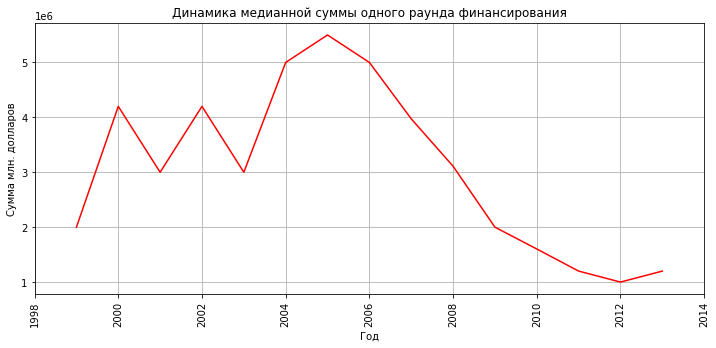

In [40]:
ax = filtered_pivot.plot(kind = 'line', y = 'raised_amount', xlabel = 'Год', ylabel = 'Сумма млн. долларов', 
                         color = 'red', rot = 90, figsize = (12,5), legend = False, grid = True)

ax.set_xlim([1998, 2014])
plt.title('Динамика медианной суммы одного раунда финансирования')
plt.show()

1. Типичный размер собранных в рамках одного раунда средств был максимален в 2005 году и составлял 5 500 000
2. В 2013 году наблюдается тенденция к значительному увеличению количества раундов финансирования в год - всего 11702 раунда финансирования за год. Это больше, чем за всю историю наблюдений по имеющимся данным. При этом медианная сумма одного раунда финансирования на 20% больше цифр 2012 году и остается на уровне 2011 - 1 200 000. Подробнее рассмотрим динамику показателей в течении 2013 года:

In [41]:
df_car_2013 = df_car_year[df_car_year['year'] == 2013]

df_car_2013['month'] = df_car_2013['funded_at'].dt.month

pivot_2013 = pd.pivot_table(df_car_2013, index = 'month', 
                            values = ['raised_amount','funding_round_id'], 
                            aggfunc = {'raised_amount':'median','funding_round_id':'count'})
pivot_2013

/tmp/ipykernel_109/2562421091.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_car_2013['month'] = df_car_2013['funded_at'].dt.month


,funding_round_id,raised_amount
month,,
1,1024,700000.0
2,740,1000000.0
3,865,750000.0
4,927,1100000.0
5,951,1037500.0
6,1039,1200000.0
7,1017,1500000.0
8,977,1000000.0
9,1064,1400000.0


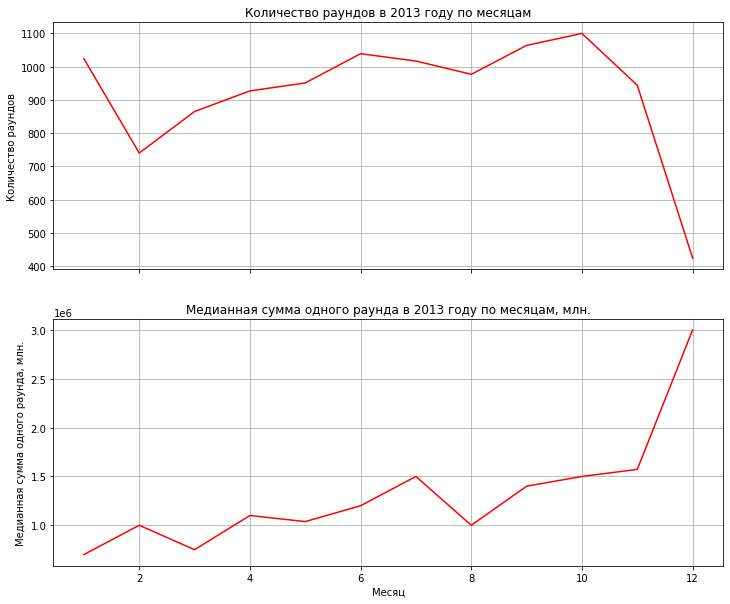

In [42]:
axes = pivot_2013.plot.line(color = 'red', subplots = True,
                       sharey = False, sharex = True, 
                       y = ['funding_round_id','raised_amount'],
                           title = ['Количество раундов в 2013 году по месяцам','Медианная сумма одного раунда в 2013 году по месяцам, млн.'],
                           figsize = (12,10), legend = False, grid = True)

axes[0].set_ylabel('Количество раундов')
axes[1].set_ylabel('Медианная сумма одного раунда, млн.')
plt.xlabel('Месяц')


plt.show()

Видим на графике, что в конце 2013 года в декабре наблюдается явная тенденция к увеличению медианной суммы одного раунда при значительном уменьшении количества раундов в месяц. Скорее всего имеем дело с положительными выбросами по сумме при общем уменьшении количества раундов финансирования. До декабря в течении всего года наблюдается небольшой прирост медианной суммы от месяца к месяцу с незначительным отклонением от тенденции в августе. Количество раундов финансирования колеблется в пределах от 750 до 1100 раундов в месяц, показывает рост от февраля к октябрю и резкий спад начиная с ноября.

#### Люди и их образование
Неоходимо выяснить, зависит ли полнота сведений о сотрудниках (например, об их образовании) от размера компаний и оценить, насколько информация об образовании сотрудников полна.

**План:**

1. Используя датасеты people.csv и education.csv, разделим все компании на несколько групп по количеству сотрудников и оценим среднюю долю сотрудников без информации об образовании в каждой из групп. *Обоснуйте выбранные границы групп.*
2. Примем решение, возможно ли для выполнения задания присоединить к этим таблицам ещё и таблицу degrees.csv.

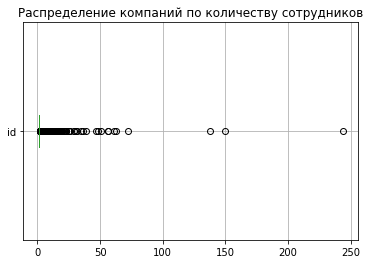

In [43]:
# сгруппируем сотрудников по компаниям, чтобы разделить компании на группы по численности
df_staff_ser = df_people_types.groupby('company_id')['id'].count()
df_staff = df_staff_ser.reset_index()
df_staff = df_staff.sort_values(by = 'id', ascending = False)

# построим диаграмму размаха, чтобы определить границы групп
bp = df_staff.boxplot(column = 'id', vert = False)

plt.title('Распределение компаний по количеству сотрудников')
plt.show()

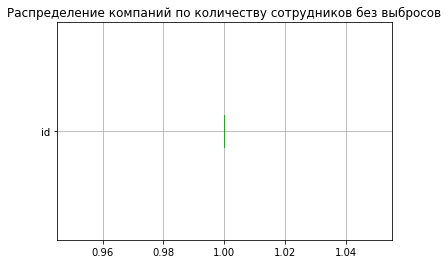

In [44]:
# добавим диаграмму размаха без выбросов
bp = df_staff.boxplot(column = 'id', vert = False, showfliers = False)

plt.title('Распределение компаний по количеству сотрудников без выбросов')
plt.show()

Вероятно, большинство компании имеют информацию только об одном сотруднике, чтобы составить более полное представление о распределении данных, отфильтруем наиболее распространенное значение:

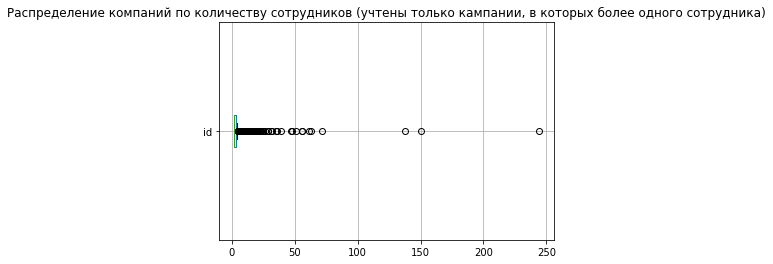

In [45]:
df_staff_filtered = df_staff[df_staff['id'] > 1]

bp = df_staff_filtered.boxplot(column = 'id', vert = False)

plt.title('Распределение компаний по количеству сотрудников (учтены только кампании, в которых более одного сотрудника)')
plt.show()

Даже после фильтрации диаграмме размаха выглядит неинформативно, представим числовой ряд в Series:

In [46]:
count_by_staff = df_staff.groupby('id')['company_id'].nunique()
count_by_staff

id
1      18117
2       2709
3        921
4        450
5        237
6        138
7        100
8         59
9         46
10        25
11        30
12        16
13        17
14         8
15         3
16         4
17         5
18         3
19         3
20         3
21         2
22         2
23         3
25         2
26         1
29         2
31         1
32         1
35         1
36         1
39         1
47         1
48         1
51         1
56         2
61         1
63         1
72         1
138        1
150        1
244        1
Name: company_id, dtype: int64

Первый столбец - количество сотрудников в компании, второй - количество кампании с таким штатом. Видно, что подавляющее большинство компаний имеет информацию только об одном сотруднике. Выделим следующие группы:

**Важно! Здесь и далее предполагаем, что в наших данных есть информация о всех сотрудниках компании. Что на самом деле, учитывая качество и чистоту данных, вообще спорное утверждение**

* **1:** 1 сотрудник - это самая большая группа, преполагаю, что единственный сотрудник - это основатель компании.
* **2:** 2 сотрудника - вероятно всего два сотрудника в компании это так же основатели. Но это другой тип компании - основанный командой, процессы могут отличаться. 
* **3:** 3-6 сотрудников - при таком количестве сотрудников скорее всего в кампании появились наемные сотрудники, но их немного, значит компания находится в начале пути.
* **4:** 7-14 сотрудников - развивающаяся кампания, в которой обязанности сотрудников уже значительно специализированы, их образование может иметь разный профиль и тип.
* **5:** 15-30 сотрудников - растущая кампания, в которой наслаживаются бизнес-процессы, есть сотрудники разных профилей.
* **6:** 31-244 сотрудника - большая кампания, с потенциально устоявшимися бизнес-процессами.


In [47]:
# добавим в датафрейм с количеством сотрудников категорию
df_staff['staff_amt_cat'] = pd.cut(df_staff['id'], bins = [0,1,2,6,14,30,244], 
                                   labels = ['1 сотрудник','2 сотрудника','3-6 сотрудников',
                                             '7-14 сотрудников','15-30 сотрудников','31-244 сотрудника'])

df_staff.head()

,company_id,id,staff_amt_cat
48,59.0,244,31-244 сотрудника
25,29.0,150,31-244 сотрудника
777,1242.0,138,31-244 сотрудника
20605,231067.0,72,31-244 сотрудника
378,499.0,63,31-244 сотрудника


In [48]:
#создадим датафрейм, где для каждой компании будет доля сотрудников без данных об образовании
# сначала объединим два датафрейма
df_education_merged = df_people_types.merge(df_education_types, how = 'left', left_on = 'id', right_on = 'person_id')
df_education_merged.head()

,id_x,first_name,last_name,company_id,network_username,id_y,person_id,instituition,graduated_at
0,10,Mark,Zuckerberg,5.0,NaN,2415.0,10.0,Harvard University,NaT
1,100,Peter,Lester,27.0,NaN,NaN,NaN,NaN,NaT
2,1000,Dr. Steven,E. Saunders,292.0,NaN,NaN,NaN,NaN,NaT
3,10000,Neil,Capel,2526.0,NaN,NaN,NaN,NaN,NaT
4,100000,Sue,Pilsch,NaN,NaN,NaN,NaN,NaN,NaT


На этом этапе видим, что в таблице education для каждого сотрудника зачастую встречается более одной строки.

In [49]:
# добавляем столбец с бинарным признаком: есть/нет данных об образовании - есть ли пропуск в столбце instituition
def create_is_na(x):
    """
    Функция создаёт новый столбец с бинарным признаком, который указывает
    на наличие данных в столбце. Функция применяется к столбцу после метода isna()
    """
    if x:
        return 0
    return 1

df_education_merged['has_education_data'] = df_education_merged['instituition'].isna().apply(create_is_na)
df_education_merged.head()


,id_x,first_name,last_name,company_id,network_username,id_y,person_id,instituition,graduated_at,has_education_data
0,10,Mark,Zuckerberg,5.0,NaN,2415.0,10.0,Harvard University,NaT,1
1,100,Peter,Lester,27.0,NaN,NaN,NaN,NaN,NaT,0
2,1000,Dr. Steven,E. Saunders,292.0,NaN,NaN,NaN,NaN,NaT,0
3,10000,Neil,Capel,2526.0,NaN,NaN,NaN,NaN,NaT,0
4,100000,Sue,Pilsch,NaN,NaN,NaN,NaN,NaN,NaT,0


In [50]:
# сгруппируем полученный датасет по id сотрудника, чтобы избавиться от дублирующихся строк для одного сотрудника
unique_people_ser = df_education_merged.groupby('id_x').agg({'company_id':'min','has_education_data':'max'})
unique_people = unique_people_ser.reset_index()

unique_people.head()



,id_x,company_id,has_education_data
0,2,4993.0,1
1,3,1.0,1
2,4,3.0,0
3,5,3.0,1
4,6,16441.0,1


In [51]:
# группируем полученный датафрейм с уникальными сотрудниками, чтобы получить для каждой компании долю сотрудников с данными об образовании
education_series = unique_people.groupby('company_id').agg({'has_education_data':'sum','id_x':'count'})
education_by_company = education_series.reset_index()
education_by_company['share'] = education_by_company['has_education_data'] / education_by_company['id_x']

education_by_company = education_by_company.rename(columns = {'id_x':'staff_amt'})

education_by_company.head()

,company_id,has_education_data,staff_amt,share
0,1.0,1,2,0.500000
1,2.0,1,1,1.000000
2,3.0,2,3,0.666667
3,4.0,12,13,0.923077
4,5.0,45,61,0.737705


In [52]:
# объединим датафреймы с категорией компании и долей сотрудников с данными об образовании

df_staff_merged = df_staff.merge(education_by_company, on = 'company_id', how = 'left')

df_staff_merged = df_staff_merged.rename(columns = {'id':'staff_amt_1'})

df_staff_merged.head()

,company_id,staff_amt_1,staff_amt_cat,has_education_data,staff_amt,share
0,59.0,244,31-244 сотрудника,168.0,244.0,0.688525
1,29.0,150,31-244 сотрудника,110.0,150.0,0.733333
2,1242.0,138,31-244 сотрудника,101.0,138.0,0.731884
3,231067.0,72,31-244 сотрудника,58.0,72.0,0.805556
4,499.0,63,31-244 сотрудника,43.0,63.0,0.682540


In [53]:
# сгруппируем данные по категории, чтобы рассчитать среднюю долю для каждой категории

ser_by_cat = df_staff_merged.groupby('staff_amt_cat')['share'].mean()
share_by_cat = ser_by_cat.reset_index()
share_by_cat

,staff_amt_cat,share
0,1 сотрудник,0.536929
1,2 сотрудника,0.533407
2,3-6 сотрудников,0.505193
3,7-14 сотрудников,0.483485
4,15-30 сотрудников,0.533389
5,31-244 сотрудника,0.759946


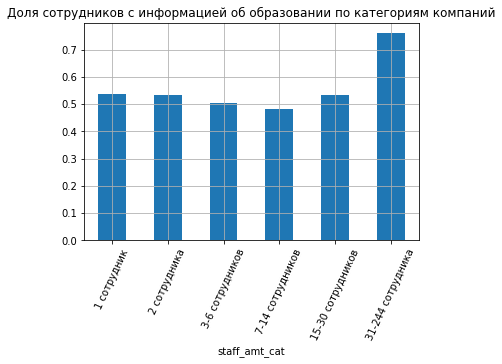

In [54]:
ser_by_cat.plot(kind = 'bar', rot = 65, grid = True, )

plt.title('Доля сотрудников с информацией об образовании по категориям компаний')
plt.show()

Доля сотрудников с доступной информацией об образовании значительно выше в крупных кампаниях (31-244 сотрудника), можно предположить, что это связано с налаженными бизнес-процессами, когда в штате есть специалист, собирающий данные о сотрудниках. Однако для формирования более обоснованной гипотезы необходимо уточнить, каким образом были собраны данные об образовании

##### Таблица degrees
Ответим на вопрос: возможно ли для выполнения задания присоединить к этим таблицам ещё и таблицу degrees.csv. В этой таблице так же есть столбец с идентификатором сотрудника `object_id` - в [первой части проекта](#degrees) я удалила лишние символы из значений этого столбца 


In [55]:
df_degrees_types.head()

,id,object_id,degree_type,subject
0,1,6117,MBA,NaN
1,2,6136,BA,"English, French"
2,3,6136,MS,Mass Communication
3,4,6005,MS,Internet Technology
4,5,5832,BCS,"Computer Science, Psychology"


In [56]:
# пробуем присоединить
degrees_merged = df_people_types.merge(df_degrees_types, left_on = 'id', right_on = 'object_id')
degrees_merged.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 109056 entries, 0 to 109055
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id_x              109056 non-null  int64  
 1   first_name        109056 non-null  object 
 2   last_name         109056 non-null  object 
 3   company_id        28638 non-null   float64
 4   network_username  33575 non-null   object 
 5   id_y              109056 non-null  int64  
 6   object_id         109056 non-null  int64  
 7   degree_type       97886 non-null   object 
 8   subject           80890 non-null   object 
dtypes: float64(1), int64(3), object(5)
memory usage: 8.3+ MB


Объединение типа inner дает ненулевой результат, значит, ответ на вопрос - да, можно присоединить датасет degrees.

#### Объединение датафреймов по столбцу network_username
Выясним, можно ли использовать столбец для объединения. Столбец `network_username` есть в датасетах company_and_rounds и people. Предполагаю, что нельзя использовать его для объединения, т.к. в company_and_rounds он содержит ник компании в соцсети, а в people - ник сотрудника, проверим это:

In [57]:
df_car_names = df_car_types[~df_car_types['network_username'].isna()]

df_car_names[['name','network_username']].head(20)

,name,network_username
0,Wetpaint,BachelrWetpaint
1,Wetpaint,BachelrWetpaint
2,Wetpaint,BachelrWetpaint
9,HostNine,Hostnine
11,Vetter Idea Management System,getvetter
12,ChatRandom,chatrandom
15,FriendFeed,friendfeed
19,The Adory,the_adory
20,Mobclix,mobclix
21,Fitbit,fitbit


In [58]:
df_people_names = df_people_types[~df_people_types['network_username'].isna()]
df_people_names[['first_name','last_name','network_username']].head(10)

,first_name,last_name,network_username
6,Courtney,Homer,jobsbostontech
8,Michael,Dadashyan,fbroulette
16,Adam,Beckerman,adam_beckerman
17,Melissa,French,netcastles
18,OÄuz KaÄan,Aslan,OguzKaganAslan
19,Neil,Chandran,neilchandran
23,Suraj,Shinde,SurajBShinde
26,Sandeep,Hegde,sandeephegde
27,Dejan,Avramovic,avramavram
29,Anand,Mistry,AnandHMistry


In [59]:
company_username = set(df_car_types['network_username'].dropna())
people_username = set(df_people_types['network_username'].dropna())

intersection = len(company_username & people_username)
intersection 

2199

In [60]:
intersection_share = round(intersection  / df_car_types.shape[0] * 100, 2)
display(f'{intersection_share}%')

'1.01%'

По соответствию названий кампаний никам в первом случае и имен сотрудников никам во втором случае можно с уверенностью сказать, что теория о разном происхождении никнеймов в этих таблицах подтверждена (кроме того это было указано в описании данных в начале проекта). Множества уникальных значений этих столбцов пересекаются всего на 2199 значений, что составляет 1% от количества строк датафрейма company_and_round - объединение такого объема не поможет в ответах на исследовательские вопросы.

#### Проблемный датасет и причина возникновения пропусков
В дататасете company_and_rounds.csv много пропусков в информации о раундах, которая заказчику важна.

1. Приведем данные в вид, который позволит в дальнейшем проводить анализ в разрезе отдельных компаний. Обратим внимание на структуру датасета, порядок и названия столбцов, проанализируем значения.
Как мы ранее отмечали, данные по компаниям из этой таблицы раньше хранились иначе, более удобным для исследования образом.

2. Максимальным образом сохраняя данные, сохранив их связность и исключив возможные возникающие при этом ошибки, подготовим данные так, чтобы удобно было отобрать компании по параметрам и рассчитать показатели из расчёта на одну компанию без промежуточных агрегаций.

In [61]:
df_car_types.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217774 entries, 0 to 217773
Data columns (total 23 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   company_id           217472 non-null  float64       
 1   name                 217472 non-null  object        
 2   category_code        143886 non-null  object        
 3   status               217472 non-null  object        
 4   founded_at           109956 non-null  datetime64[ns]
 5   closed_at            3449 non-null    datetime64[ns]
 6   domain               147159 non-null  object        
 7   network_username     95534 non-null   object        
 8   country_code         108607 non-null  object        
 9   investment_rounds    217472 non-null  float64       
 10  funding_rounds       217472 non-null  float64       
 11  funding_total        217472 non-null  float64       
 12  milestones           217472 non-null  float64       
 13  funding_round_

In [62]:
df_car_types.head()

,company_id,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,...,funding_round_id,company_id_2,funded_at,funding_round_type,raised_amount,pre_money_valuation,participants,is_first_round,is_last_round,year
0,1.0,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,888.0,1.0,2005-10-01,series-a,5250000.0,0.0,2.0,0.0,1.0,2005.0
1,1.0,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,889.0,1.0,2007-01-01,series-b,9500000.0,0.0,3.0,0.0,0.0,2007.0
2,1.0,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,2312.0,1.0,2008-05-19,series-c+,25000000.0,0.0,4.0,1.0,0.0,2008.0
3,10.0,Flektor,games_video,acquired,NaT,NaT,flektor.com,NaN,USA,0.0,...,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,100.0,There,games_video,acquired,NaT,NaT,there.com,NaN,USA,0.0,...,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN


##### Оценка содержания столбцов

По количеству пропусков можно отметить, что есть ряд столбцов, в которых пропусков 164846: `funding_round_id`,
`company_id_2`, `funded_at`, `funding_round_type`, `raised_amount`, `pre_money_valuation`, `participants`, `is_first_round`, `is_last_round` - предполагаю, что это последствия объединения двух исходных датасетов: **rounds** и **company** объединенные методом `outer`, при этом:
* не для всех компаний есть информация о раундах финансирования: есть 164846 строк с уникальными идентификаторами компаний, не имеющих информации о раундах финансирования, предполагаю, что у этих компаний не было ни одного раунда финансирования. 
* у одной компании может быть более одного раунда финансирования.
* не у всех раундов финансирования есть информация о компании: есть 302 строки с информацией о раундах финансирования, для которых нет никакой информации о компании, кроме идентификатора в `company_id_2`.

Столбец `investment_rounds` содержит нули в трех первых строках, где очевидно должны быть ненулевые значения. Необходимо проверить, есть ли в этом столбце что-то кроме нулей.

`funding_total` должен представлять сумму всех `raised_amount` согласно описанию должны содержать одну и ту же информацию о сумме финансирования

Названия столбцов содержат верхний регистр и двойной пробел в качестве разделителя, для оптимизации их частого упоминания в коде необходимо привести к  snake case.

**Предварительный план**

1. Нормализовать названия компании и проверить на наличие неявных дубликатов. 
2. Проверить наличие ненулевых значений в столбце `investment  rounds`.
3. Сравнить значения в столбцах `funding  total` и `raised  amount`, сделать выводы об источнике данных и сформировать более информативное описание.


In [63]:
# сначала проверим наличие явных дубликатов в датафрейме
df_car_types.duplicated().sum()

0

In [64]:
# проверим наличие явных дубликатов по сочетанию столбцов name и funding_round_id
# заменим пропуски в столбце на 0, чтобы выделить дубликаты
df_car_types['funding_round_id'] = df_car_types['funding_round_id'].fillna(0)
df_car_types.duplicated(subset = ('name','funding_round_id')).sum()

46

In [65]:
# выведем дублирующиеся значения
ser_by_name = df_car_types.groupby(['name','funding_round_id'])['company_id'].count()
by_name = ser_by_name.reset_index()
by_name = by_name.sort_values(by = 'company_id', ascending = False)

by_name.head(10)

,name,funding_round_id,company_id
18053,BBOescape,0.0,3
125730,Olnick Organization,0.0,2
83167,IDB Holdings,0.0,2
115721,Movenpick Group,0.0,2
151350,SIMTEAM,0.0,2
49402,Design Source Furniture,0.0,2
174213,Tech Field Day,0.0,2
180811,Tip or Sip,0.0,2
83166,IDB Group,0.0,2
89278,International Space University,0.0,2


In [66]:
# выведем для примера строки с одним из дублирующихмя названий в изначальном датафрейме

df_bbo = df_car_types[df_car_types['name'] == 'BBOescape']
df_bbo

,company_id,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,...,funding_round_id,company_id_2,funded_at,funding_round_type,raised_amount,pre_money_valuation,participants,is_first_round,is_last_round,year
68443,205898.0,BBOescape,games_video,operating,2013-06-01,NaT,bboescape.com,NaN,CAN,0.0,...,0.0,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
68444,205899.0,BBOescape,games_video,operating,2013-03-30,NaT,bboescape.com,NaN,CAN,0.0,...,0.0,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
68447,205900.0,BBOescape,games_video,operating,2013-03-30,NaT,bboescape.com,NaN,CAN,0.0,...,0.0,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN


На примере компании BBOescape видим, что часть датасета с информацией о компаниях содержит неявные дубликаты: строки с одинаковыми названиями компании и разными company_id. Необходимо нормализовать столбец `name`, чтобы выявить еще дубликаты.

In [67]:
# нормализуем столбец name
df_car_names = df_car_types
df_car_names['lower_name'] = df_car_names['name'].str.lower().str.replace(' ','')

# проверим наличие явных дубликатов сочетания имени после нормализации и funding_round_id
df_car_names.duplicated(subset = ('lower_name','funding_round_id')).sum()


710

видим уже 710 дубликатов, проверим, к какой части датасета они относятся: к данным о раундах или к данным о компаниях

In [68]:
df_car_norounds = df_car_names[df_car_names['funding_round_id'] == 0]
df_car_norounds.duplicated(subset = ('lower_name','funding_round_id')).sum()

710

Все найденные дубликаты относятся к части датасета с ниформацией о компаниях, для которых не нашлось раундов финансирования. После более подробного рассмотрения столбцов `investment  rounds` и `funding_total` разделим датасет на два датафрейма: 
* в одном будет информация о компаниях, очищенная от выявленных дубликатов
* в другом: информация о раундах финансирования с уникальными `funding_round_id`

In [69]:
# сравним количество раундов финансирования в `investment  rounds` с фактическим
rounds_count_ser = df_car_types.groupby('company_id').agg({'investment_rounds':'max','company_id_2':'count'})
rounds_count = rounds_count_ser.reset_index()
rounds_count['diff'] = rounds_count['investment_rounds'] - rounds_count['company_id_2'] 

rounds_diff = rounds_count[rounds_count['diff'] != 0]
rounds_diff = rounds_diff.sort_values(by = 'diff', ascending = False)

rounds_diff.head(10)

,company_id,investment_rounds,company_id_2,diff
1957,2520.0,478.0,2,476.0
341,362.0,297.0,3,294.0
35618,44900.0,125.0,0,125.0
15857,20953.0,96.0,3,93.0
25,28.0,89.0,1,88.0
55463,66850.0,68.0,0,68.0
61463,74039.0,58.0,3,55.0
6595,8885.0,51.0,1,50.0
93345,168371.0,49.0,1,48.0
58560,70343.0,44.0,0,44.0


Количество раундов в столбце `investment_rounds` не совпадает с количеством раундов финансирования, о которых у нас есть данные. Использовать этот столбец так же не получится, можем удалить его из будущего датасета с информацией о компаниях.

In [70]:
# выясним, всегда ли `funding_total` равен сумме всех `raised_amount` для компании
df_car_funding_total = df_car_types[df_car_types['funding_total'] > 0]

funding_grouped_ser = df_car_funding_total.groupby('company_id').agg({'funding_total':'max','raised_amount':'sum'})

funding_grouped = funding_grouped_ser.reset_index()

funding_grouped['diff'] = funding_grouped['funding_total'] - funding_grouped['raised_amount']

df_diff = funding_grouped[funding_grouped['diff'] != 0]

df_diff = df_diff.sort_values(by = 'diff', ascending = False)

df_diff.head(15)

,company_id,funding_total,raised_amount,diff
5,12.0,1.160170e+09,1.160167e+09,3490.0
2489,11391.0,1.147290e+09,1.147288e+09,1600.0
3150,16142.0,1.005920e+08,1.005915e+08,500.0
7719,39343.0,1.100050e+08,1.100045e+08,500.0
6974,36590.0,1.124380e+08,1.124375e+08,500.0
6818,35592.0,1.155780e+08,1.155775e+08,500.0
13000,65611.0,1.382360e+08,1.382355e+08,500.0
10087,47630.0,1.254400e+08,1.254395e+08,500.0
24498,247225.0,2.575480e+08,2.575475e+08,500.0
7514,38594.0,1.453640e+08,1.453635e+08,500.0


Видим, что расхождения, хоть и небольшие, имеются. Будет корректно удалить столбец `funding_total` и использовать для рассчета сумм `raised_amount`

In [71]:
# сравним количество раундов финансирования в `funding_rounds` с фактическим
rounds_count_ser_1 = df_car_types.groupby('company_id').agg({'funding_rounds':'max','company_id_2':'count'})
rounds_count_1 = rounds_count_ser_1.reset_index()
rounds_count_1['diff'] = rounds_count_1['funding_rounds'] - rounds_count_1['company_id_2'] 

rounds_diff_1 = rounds_count_1[rounds_count_1['diff'] != 0]
rounds_diff_1 = rounds_diff_1.sort_values(by = 'diff', ascending = False)

rounds_diff_1.head(10)

,company_id,funding_rounds,company_id_2,diff


Количество раундов в столбце `funding_rounds` совпадает с фактическим, можем оставить его в датасете companies после разделения

In [72]:
df_car_names.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217774 entries, 0 to 217773
Data columns (total 24 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   company_id           217472 non-null  float64       
 1   name                 217472 non-null  object        
 2   category_code        143886 non-null  object        
 3   status               217472 non-null  object        
 4   founded_at           109956 non-null  datetime64[ns]
 5   closed_at            3449 non-null    datetime64[ns]
 6   domain               147159 non-null  object        
 7   network_username     95534 non-null   object        
 8   country_code         108607 non-null  object        
 9   investment_rounds    217472 non-null  float64       
 10  funding_rounds       217472 non-null  float64       
 11  funding_total        217472 non-null  float64       
 12  milestones           217472 non-null  float64       
 13  funding_round_

In [73]:
df_companies = df_car_names[['company_id','name','category_code','status',
                             'founded_at','closed_at','domain','network_username',
                             'country_code','funding_rounds','milestones','lower_name']]

df_companies_unique = df_companies.drop_duplicates(subset = ('lower_name'), keep = 'first')

df_companies_unique.info()


<class 'pandas.core.frame.DataFrame'>
Int64Index: 195538 entries, 0 to 217472
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   company_id        195537 non-null  float64       
 1   name              195537 non-null  object        
 2   category_code     122648 non-null  object        
 3   status            195537 non-null  object        
 4   founded_at        90782 non-null   datetime64[ns]
 5   closed_at         2611 non-null    datetime64[ns]
 6   domain            125993 non-null  object        
 7   network_username  80177 non-null   object        
 8   country_code      87568 non-null   object        
 9   funding_rounds    195537 non-null  float64       
 10  milestones        195537 non-null  float64       
 11  lower_name        195537 non-null  object        
dtypes: datetime64[ns](2), float64(3), object(7)
memory usage: 19.4+ MB


In [74]:
df_rounds_with0 = df_car_names[['funding_round_id','company_id_2','funded_at',
                          'funding_round_type','raised_amount','pre_money_valuation',
                          'participants','is_first_round','is_last_round','year']]

df_rounds = df_rounds_with0[df_rounds_with0['funding_round_id'] != 0]

df_rounds = df_rounds.rename(columns = {'company_id_2':'company_id'})
df_rounds.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 52928 entries, 0 to 217773
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   funding_round_id     52928 non-null  float64       
 1   company_id           52928 non-null  float64       
 2   funded_at            52680 non-null  datetime64[ns]
 3   funding_round_type   52928 non-null  object        
 4   raised_amount        52928 non-null  float64       
 5   pre_money_valuation  52928 non-null  float64       
 6   participants         52928 non-null  float64       
 7   is_first_round       52928 non-null  float64       
 8   is_last_round        52928 non-null  float64       
 9   year                 52680 non-null  float64       
dtypes: datetime64[ns](1), float64(8), object(1)
memory usage: 4.4+ MB


### Вывод
###### Проделанная работа
1. Проведен анализ динамики количества раундов и медианной суммы одного раунда, выявлены тенденции:
   * Типичный размер собранных в рамках одного раунда средств был максимален в 2005 году и составлял 5 500 000
   * В 2013 году наблюдается тенденция к значительному увеличению количества раундов финансирования в год - всего 11702 раунда финансирования за год. Это больше, чем за всю историю наблюдений по имеющимся данным. При этом медианная сумма одного раунда финансирования на 20% больше цифр 2012 году и остается на уровне 2011 - 1 200 000.
   * По 2013 году: в конце 2013 года в декабре наблюдается явная тенденция к увеличению медианной суммы одного раунда при значительном уменьшении количества раундов в месяц. Скорее всего имеем дело с положительными выбросами по сумме при общем уменьшении количества раундов финансирования. До декабря в течении всего года наблюдается небольшой прирост медианной суммы от месяца к месяцу с незначительным отклонением от тенденции в августе. Количество раундов финансирования колеблется в пределах от 750 до 1100 раундов в месяц, показывает рост от февраля к октябрю и резкий спад начиная с ноября.
2. Проведен анализ полноты данных об образовании сотрудников:
   * Подавляющее большинство компании имеют информацию только об одном сотруднике. Самая крупная компания по нашим данным имеет 244 сотрудника.
   * Доля сотрудников с доступной информацией об образовании значительно выше в крупных кампаниях (31-244 сотрудника), можно предположить, что это связано с налаженными бизнес-процессами, когда в штате есть специалист, собирающий данные о сотрудниках. Однако для формирования более обоснованной гипотезы необходимо уточнить, каким образом были собраны данные об образовании.
   * При необходимости можем присоединить датасет с данными о типе образования (degrees) к объединенному датасету о сотрудниках и их образовании, однако с учетом пропусков это будет малоэффективно.
3. Исследована возможность использования столбца `network_username` - он содержит разную информацию в разных таблицах и не может быть использован для присоединения.
4. Подробно оценен датасет company_and_rounds:

   * Датасет образован из двух исходных датасетов: rounds и company объединенных методом outer.
   * В исходном датасете company найдено и удалено 710 неявных дубликатов. Проверены столбцы `funding_rounds`, `investment_rounds`, `funding_total`. `funding_rounds` соответствует данным из таблицы rounds, а `investment_rounds`, `funding_total` имеют расхождения с таблицей rounds и не могут участвовать в дальнейшем исследовании.
   * Датасет разделен на два:
     - `df_companies_unique`: 195537 строк, 12 столбцов. Содержит информацию об уникальных компаниях.
     - `df_rounds`: 52928 строк, 10 столбцов. Содержит информацию о раундах финансирования и столбец `company_id`, подходящий для объединения с датасетом `df_companies_unique`.

Можно приступать к анализу данных в полученных датасетах.

### Исследовательский анализ объединенных таблиц 
#### Объединение данных
Необходимо объединить данные для ответа на вопросы в отношении компаний, которые меняли владельца и/или получали инфестиции или финансирование. 
Для этого отберем в датасете `df_companies_unique` компании, у которых `funding_rounds` больше 0 или в стольце `status` указано значение 'acquired'

In [75]:
# убедимся, что написания статусов уникальны и нужно учесть только один вариант для фильтрации
df_companies_unique['status'].value_counts()

operating    182508
acquired       9331
closed         2575
ipo            1123
Name: status, dtype: int64

In [76]:
df_actual = df_companies_unique[(df_companies_unique['funding_rounds'] > 0 ) | (df_companies_unique['status'] == 'acquired')]
df_actual.shape[0]

38300

In [77]:
df_actual.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 38300 entries, 0 to 217469
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   company_id        38300 non-null  float64       
 1   name              38300 non-null  object        
 2   category_code     34327 non-null  object        
 3   status            38300 non-null  object        
 4   founded_at        27028 non-null  datetime64[ns]
 5   closed_at         2117 non-null   datetime64[ns]
 6   domain            34568 non-null  object        
 7   network_username  20156 non-null  object        
 8   country_code      33614 non-null  object        
 9   funding_rounds    38300 non-null  float64       
 10  milestones        38300 non-null  float64       
 11  lower_name        38300 non-null  object        
dtypes: datetime64[ns](2), float64(3), object(7)
memory usage: 3.8+ MB


В результате объединения получен датасет с информацией о компаниях, которые были проданы и / или получали инвестиции. Всего 38300 строк.
#### Анализ выбросов
Выясняем обычный для рассматриваемого периода размер средств, который предоставлялся компаниям: какой размер общего финансирования для одной компании будет типичным, а какой — выбивающимся.

План:
1. Создаем новый столбец с общей суммой финансирования вместо удаленного `funding_total`.
2. Анализируем распределение значений и меры центральной тенденции для столбца.


In [78]:
df_merged_car = df_actual.merge(df_rounds, how = 'left', on = 'company_id')

df_merged_car.head()

,company_id,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,funding_rounds,...,lower_name,funding_round_id,funded_at,funding_round_type,raised_amount,pre_money_valuation,participants,is_first_round,is_last_round,year
0,1.0,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,3.0,...,wetpaint,888.0,2005-10-01,series-a,5250000.0,0.0,2.0,0.0,1.0,2005.0
1,1.0,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,3.0,...,wetpaint,889.0,2007-01-01,series-b,9500000.0,0.0,3.0,0.0,0.0,2007.0
2,1.0,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,3.0,...,wetpaint,2312.0,2008-05-19,series-c+,25000000.0,0.0,4.0,1.0,0.0,2008.0
3,10.0,Flektor,games_video,acquired,NaT,NaT,flektor.com,NaN,USA,0.0,...,flektor,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,100.0,There,games_video,acquired,NaT,NaT,there.com,NaN,USA,0.0,...,there,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [79]:
total_funding_ser = df_merged_car.groupby('company_id').agg({'name':'min', 
                                                             'status':'min', 
                                                             'funding_round_id':'count',
                                                             'raised_amount':'sum', 
                                                             'category_code':'min', 
                                                             'founded_at':'min',
                                                             'closed_at':'min', 
                                                             'country_code':'min',
                                                             'funded_at':'min'})
total_funding = total_funding_ser.reset_index()
total_funding = total_funding.rename(columns = {'raised_amount':'raised_total','funding_round_id':'rounds_count'})
total_funding.head()

,company_id,name,status,rounds_count,raised_total,category_code,founded_at,closed_at,country_code,funded_at
0,1.0,Wetpaint,operating,3,3.975000e+07,web,2005-10-17,NaT,USA,2005-10-01
1,4.0,Digg,acquired,4,4.500000e+07,news,2004-10-11,NaT,USA,2005-10-01
2,5.0,Socialnet,ipo,11,2.425700e+09,social,2004-02-01,NaT,USA,2004-09-01
3,7.0,Omnidrive,closed,1,8.000000e+05,network_hosting,2005-11-01,2008-09-15,ISR,2006-12-01
4,8.0,Postini,acquired,0,0.000000e+00,web,1999-06-02,NaT,USA,NaT


In [80]:
total_funding['raised_total'].describe()

count    3.830000e+04
mean     1.067975e+07
std      5.810699e+07
min      0.000000e+00
25%      0.000000e+00
50%      8.157305e+05
75%      6.250000e+06
max      5.700000e+09
Name: raised_total, dtype: float64

Получили экспоненциальный формат значений в результате метода describe, попробуем получить стандартный формат:

In [81]:
total_funding['raised_total_mln'] = total_funding['raised_total'] / 1000000

total_funding.head(12)

,company_id,name,status,rounds_count,raised_total,category_code,founded_at,closed_at,country_code,funded_at,raised_total_mln
0,1.0,Wetpaint,operating,3,3.975000e+07,web,2005-10-17,NaT,USA,2005-10-01,39.75000
1,4.0,Digg,acquired,4,4.500000e+07,news,2004-10-11,NaT,USA,2005-10-01,45.00000
2,5.0,Socialnet,ipo,11,2.425700e+09,social,2004-02-01,NaT,USA,2004-09-01,2425.70000
3,7.0,Omnidrive,closed,1,8.000000e+05,network_hosting,2005-11-01,2008-09-15,ISR,2006-12-01,0.80000
4,8.0,Postini,acquired,0,0.000000e+00,web,1999-06-02,NaT,USA,NaT,0.00000
5,9.0,Geni,acquired,3,1.650000e+07,web,2006-06-01,NaT,USA,2007-01-01,16.50000
6,10.0,Flektor,acquired,0,0.000000e+00,games_video,NaT,NaT,USA,NaT,0.00000
7,12.0,Network,ipo,8,1.160167e+09,social,2006-03-21,NaT,USA,2007-07-01,1160.16651
8,13.0,StumbleUpon,acquired,4,1.850000e+07,web,2002-02-01,NaT,USA,2001-01-01,18.50000
9,14.0,Gizmoz,acquired,3,1.810000e+07,web,2003-01-01,NaT,USA,2007-05-01,18.10000


In [82]:
total_funding['raised_total_mln'].describe()

count    38300.000000
mean        10.679750
std         58.106994
min          0.000000
25%          0.000000
50%          0.815731
75%          6.250000
max       5700.000000
Name: raised_total_mln, dtype: float64

# По результатам метода describe можем предположить:
1. Имеем большое количество нулевых значений - первый квартиль полностью состоит из нулей. Нужно проанализировать распределение без учета нулевых значений, но при формировании выводов стоит учитывать, что в выборке есть значительное количество компаний, которые были проданы и не получали инвестиций.
2. Среднее значение (10,6 млн) значительно больше медианы (0.81 млн) как раз раз счет большого количества нулевых значений. 
3. Максимум является ярко выраженным выбросом. И то, что стандартное отклонение намного больше среднего арифметического - говорит о том, что положительных выбросов может быть много.

Попробуем визулизировать на диаграмме размаха:

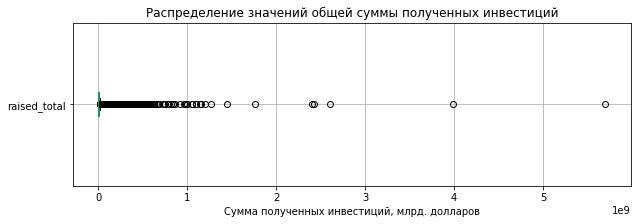

In [83]:
total_funding.boxplot(column = 'raised_total', figsize = (10,3), vert = False)

plt.xlabel('Сумма полученных инвестиций, млрд. долларов')
plt.title('Распределение значений общей суммы полученных инвестиций')
plt.show()

На диаграмме размаха видим подтверждение выводов по результатам метода describe. Попробуем отсеять нулевые значения и выбросы более двух миллиардов, но сначала оценим корректность данных

In [84]:
total_funding_sorted = total_funding.sort_values(by = 'raised_total', ascending = False)

total_funding_sorted.head(10)

,company_id,name,status,rounds_count,raised_total,category_code,founded_at,closed_at,country_code,funded_at,raised_total_mln
3879,13219.0,Clearwire,acquired,4,5.700000e+09,mobile,2003-10-01,NaT,USA,2008-05-06,5700.00000
1989,4843.0,"Verizon Communications, Inc.",ipo,2,3.985050e+09,mobile,NaT,NaT,USA,2010-01-26,3985.05000
33536,242735.0,sigmacare,operating,1,2.600000e+09,health,2005-01-01,NaT,USA,2013-07-29,2600.00000
2,5.0,Socialnet,ipo,11,2.425700e+09,social,2004-02-01,NaT,USA,2004-09-01,2425.70000
18145,64365.0,Carestream,operating,1,2.400000e+09,biotech,2007-01-01,NaT,USA,2013-06-12,2400.00000
5913,22568.0,Solyndra,operating,9,1.765504e+09,manufacturing,2005-01-01,NaT,USA,2006-01-01,1765.50400
2263,5951.0,Fisker Automotive,operating,9,1.451000e+09,automotive,2008-01-01,NaT,USA,2008-01-14,1451.00000
11239,39799.0,O3b Networks,operating,5,1.270283e+09,enterprise,2008-01-01,NaT,GBR,2009-11-13,1270.28300
6499,24693.0,Terra-Gen Power,operating,1,1.200000e+09,cleantech,NaT,NaT,USA,2010-07-21,1200.00000
7,12.0,Network,ipo,8,1.160167e+09,social,2006-03-21,NaT,USA,2007-07-01,1160.16651


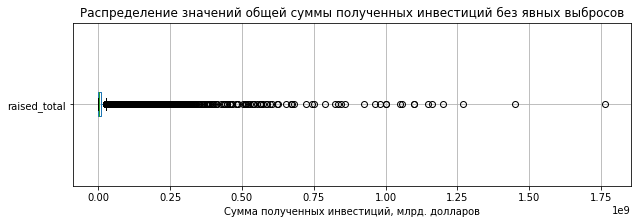

In [85]:
# отфильтруем значения равные нулю и превышающие 2 млрд для более наглядной визуализации, но не забудем учесть из при формировании выводов
total_funding_nonull = total_funding[(total_funding['raised_total'] != 0) & (total_funding['raised_total_mln'] < 2000)]

total_funding_nonull.boxplot(column = 'raised_total', figsize = (10,3), vert = False)

plt.xlabel('Сумма полученных инвестиций, млрд. долларов')
plt.title('Распределение значений общей суммы полученных инвестиций без явных выбросов')
plt.show()

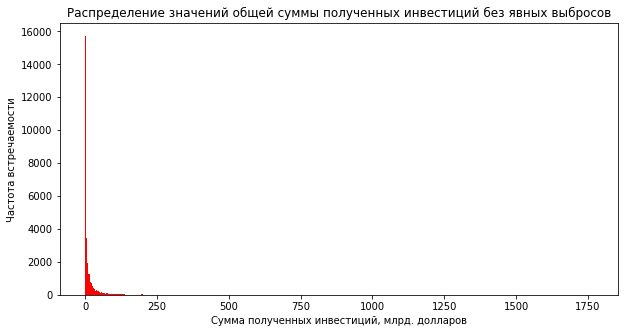

In [86]:
total_funding_nonull['raised_total_mln'].plot(kind = 'hist', color = 'red',
                                             figsize = (10,5), bins = 450)

plt.xlabel('Сумма полученных инвестиций, млрд. долларов')
plt.ylabel('Частота встречаемости')
plt.title('Распределение значений общей суммы полученных инвестиций без явных выбросов')
plt.show()


На гистограмме распределения видим нисходящий график, где для низких сумм частота встречаемости резко больше даже при большом количестве корзин. Чтобы исключить ошибку, когда в данных есть индикаторы, например `1`, посмотрим подробнее на первый квартиль:

In [87]:
total_funding_minimal = total_funding_nonull[total_funding_nonull['raised_total'] < 250000]
total_funding_minimal.shape[0]

4506

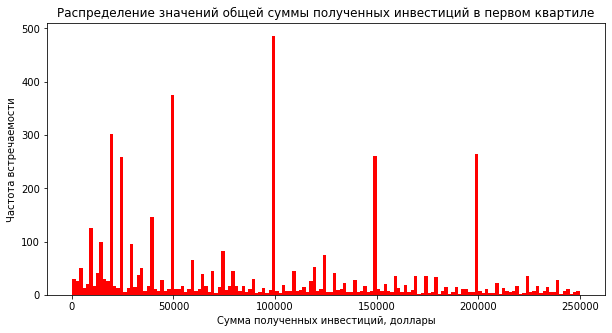

In [88]:
total_funding_minimal['raised_total'].plot(kind = 'hist', color = 'red',
                                             figsize = (10,5), bins = 150)

plt.xlabel('Сумма полученных инвестиций, доллары')
plt.ylabel('Частота встречаемости')
plt.title('Распределение значений общей суммы полученных инвестиций в первом квартиле')
plt.show()

Распределение значений в первом квартиле выглядит органично - здесь нет индикаторов. Можем сделать выводы о распределении на основе выборки за исключением нулевых сумм и двух самых больших выбросов:

In [89]:
total_funding_nonull['raised_total_mln'].describe()

count    27709.000000
mean        14.144273
std         47.060205
min          0.000291
25%          0.500000
50%          2.535300
75%         10.964640
max       1765.504000
Name: raised_total_mln, dtype: float64

###### Без учета нулевых и очень больших значений мы видим похожую картину: 
* множество небольших значений - первый квартиль расположен на небольшом отрезке и ограничивается значениями от 291 доллара до 500 тыс. долларов;
* очень большой размах: 1,76 млрд и стандартное отклонение в разы превышающее среднее арифметическое;
* среднее намного больше медианы;

В целом распределение ассиметричное с длинным правым хвостом, половина значений сконцентрированы на отрезке **от 500. тыс долларов до 11 млн долларов** - такие размеры общего финансирования для одной кампании считаем типичным.

Учитывая особенности распределения ориентироваться на среднее значение для выявления типичных значений не стоит - этот показатель значительно подвержен влиянию выборосов. Медиана более точно отражает центральную тенденцию распределения, однако, учитывая очень большой размах, стоит все же ориентироваться на границы ящика - между первым и третьим квартилем. 

Вероятнее всего, большой размах объясняется широким разнообразием характеристик компаний (сфера деятельности, количество сотрдников, оценочная стоимость, страна и пр.). Категоризация компаний поможет найти более конкретные характеристики центральной тенденции для каждой категории.

#### Бесплатные компании
* Исследуем компании, которые были проданы за ноль или за один доллар, и при этом известно, что у них был ненулевой общий объём финансирования.
* Рассчитаем аналитически верхнюю и нижнюю границу выбросов для столбца funding_total и укажите, каким процентилям границы соответствуют.

In [90]:
# объединим датафреймы
df_merged_acq = total_funding.merge(df_acq_types, left_on = 'company_id', right_on = 'acquired_company_id', how = 'left')

df_merged_acq.head()

,company_id,name,status,rounds_count,raised_total,category_code,founded_at,closed_at,country_code,funded_at,raised_total_mln,id,acquiring_company_id,acquired_company_id,term_code,price_amount,acquired_at
0,1.0,Wetpaint,operating,3,3.975000e+07,web,2005-10-17,NaT,USA,2005-10-01,39.75,NaN,NaN,NaN,NaN,NaN,NaT
1,4.0,Digg,acquired,4,4.500000e+07,news,2004-10-11,NaT,USA,2005-10-01,45.00,7386.0,20953.0,4.0,NaN,500000.0,2012-07-12
2,5.0,Socialnet,ipo,11,2.425700e+09,social,2004-02-01,NaT,USA,2004-09-01,2425.70,NaN,NaN,NaN,NaN,NaN,NaT
3,7.0,Omnidrive,closed,1,8.000000e+05,network_hosting,2005-11-01,2008-09-15,ISR,2006-12-01,0.80,NaN,NaN,NaN,NaN,NaN,NaT
4,8.0,Postini,acquired,0,0.000000e+00,web,1999-06-02,NaT,USA,NaT,0.00,419.0,59.0,8.0,cash,625000000.0,2007-07-09


In [91]:
df_sale = df_merged_acq[(df_merged_acq['price_amount'] <= 1) & (df_merged_acq['raised_total'] > 0)]
df_sale.shape[0]

1601

In [92]:
df_sale.head()

,company_id,name,status,rounds_count,raised_total,category_code,founded_at,closed_at,country_code,funded_at,raised_total_mln,id,acquiring_company_id,acquired_company_id,term_code,price_amount,acquired_at
5,9.0,Geni,acquired,3,16500000.0,web,2006-06-01,NaT,USA,2007-01-01,16.50,7954.0,687.0,9.0,NaN,0.0,2012-11-28
8,13.0,StumbleUpon,acquired,4,18500000.0,web,2002-02-01,NaT,USA,2001-01-01,18.50,4283.0,20.0,13.0,NaN,0.0,2007-05-30
10,14.0,Gizmoz,acquired,3,18100000.0,web,2003-01-01,NaT,USA,2007-05-01,18.10,2692.0,37730.0,14.0,NaN,0.0,2009-12-15
18,23.0,Joost,acquired,1,45000000.0,games_video,2006-10-01,NaT,USA,2007-05-09,45.00,2622.0,3396.0,23.0,NaN,0.0,2009-11-24
29,38.0,Kyte,acquired,4,23350000.0,games_video,2006-12-01,NaT,USA,2007-07-01,23.35,5075.0,475.0,38.0,NaN,0.0,2011-01-31


###### Всего 1601 компания была проданы за 1 или 0 долларов, при этом у них был ненулевой объем финансирования, объединили их в датафрейм `df_sale`.

Проверим, что могло повлиять на сумму сделки и вызвало аномальные значения. Переменные, которые будем проверять:

1. rounds_count - количество раундов финансирования
2. category_code - категория компании
3. country_code - страна
4. raised_total - общая сумма финансирования компании

In [93]:
# начнем с количества раундов финансирования
rounds_amt = round(df_sale['rounds_count'].value_counts() / df_sale.shape[0] * 100, 2)
rounds_amt

1     51.28
2     25.61
3     13.62
4      5.68
5      2.12
6      0.69
7      0.56
8      0.19
9      0.12
11     0.06
12     0.06
Name: rounds_count, dtype: float64

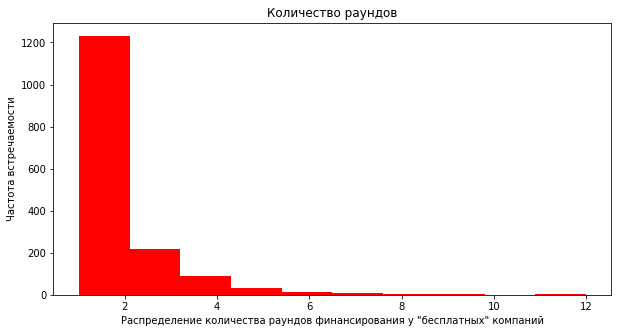

In [94]:
df_sale['rounds_count'].plot(kind = 'hist', color = 'red',
                                             figsize = (10,5), bins = 10)

plt.xlabel('Распределение количества раундов финансирования у "бесплатных" компаний')
plt.ylabel('Частота встречаемости')
plt.title('Количество раундов')
plt.show()

Более половины бесплатных компаний имели всего один раунд финансирования. 25,6% - два раунда финансирования и 13,6% - четыре раунда финансирования.
Не более 10% исследуемых компаний имели четыре и более раундов финансирования.

In [95]:
df_sale['category_code'].value_counts()

software            358
web                 215
enterprise          128
mobile              116
advertising          76
games_video          76
biotech              69
ecommerce            59
network_hosting      56
semiconductor        43
cleantech            40
hardware             36
analytics            32
security             30
public_relations     26
other                20
search               18
travel               16
messaging            16
social               16
health               13
medical              10
news                  9
education             9
consulting            9
music                 8
finance               7
fashion               5
manufacturing         3
hospitality           3
design                3
photo_video           3
automotive            2
legal                 2
transportation        2
sports                2
Name: category_code, dtype: int64

In [96]:
df_sale['category_code'].nunique()

36

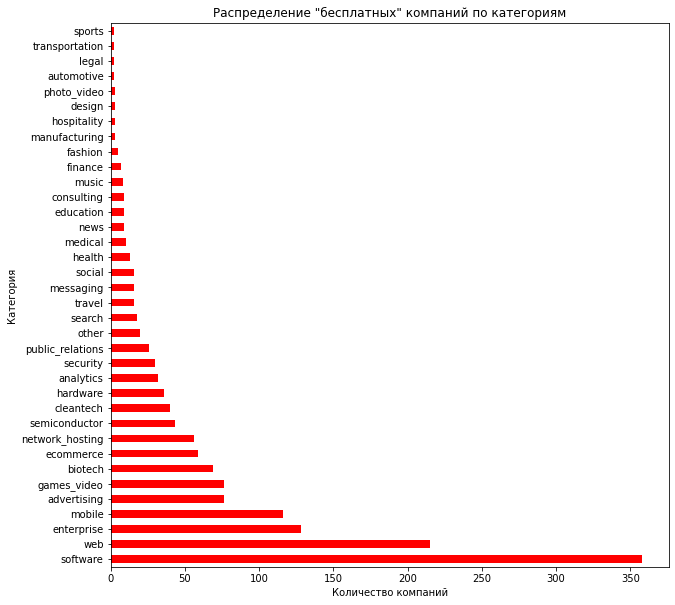

In [97]:
df_sale['category_code'].value_counts().plot(kind = 'barh', color = 'red', figsize = (10,10))

plt.xlabel('Количество компаний')
plt.ylabel('Категория')
plt.title('Распределение "бесплатных" компаний по категориям')
plt.show()

Подавляющее большинство бесплатных компаний - разработчики програмного обеспечения. Следующая по численности категория - веб разработка. В целом среди бесплатных компаний есть представители самых разных категорий - всего 36. 

In [98]:
# рассчитаем долю представленности каждой страны среди бесплатных компаний
share_of_country = round(df_sale['country_code'].value_counts() / df_sale.shape[0] * 100, 2)
share_of_country

USA    76.33
GBR     4.00
CAN     2.87
DEU     1.94
ISR     1.69
FRA     1.44
IRL     0.69
DNK     0.56
SWE     0.50
IND     0.44
FIN     0.37
ITA     0.37
ESP     0.37
CHE     0.37
NLD     0.31
JPN     0.31
CHN     0.25
BEL     0.25
ARG     0.25
NOR     0.25
AUT     0.19
SGP     0.19
AUS     0.12
BGR     0.12
CHL     0.06
POL     0.06
URY     0.06
HUN     0.06
HKG     0.06
UMI     0.06
THA     0.06
TUR     0.06
BRA     0.06
CZE     0.06
KOR     0.06
RUS     0.06
Name: country_code, dtype: float64

76% бесплатных компаний базируются в США. С большим отставанием следуют Великобритания, Канада, Германия, Израиль и Франция.

In [99]:
df_sale['raised_total_mln'].describe()

count    1601.000000
mean       18.240922
std       145.263065
min         0.003750
25%         2.000000
50%         6.000000
75%        15.500000
max      5700.000000
Name: raised_total_mln, dtype: float64

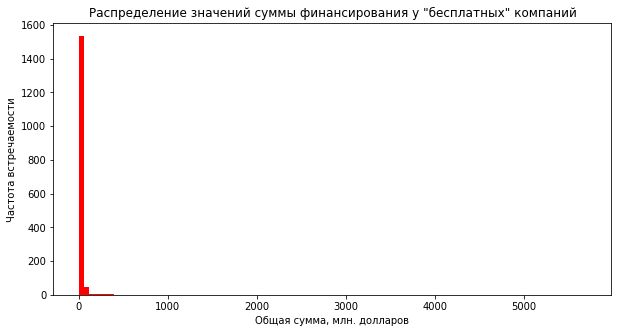

In [100]:
df_sale['raised_total_mln'].plot(kind = 'hist', color = 'red',
                                             figsize = (10,5), bins = 100)

plt.xlabel('Общая сумма, млн. долларов')
plt.ylabel('Частота встречаемости')
plt.title('Распределение значений суммы финансирования у "бесплатных" компаний')
plt.show()

Наблюдаем очевидный выброс, который делает гистограмму неинформативной, посмотрим на распределение без него

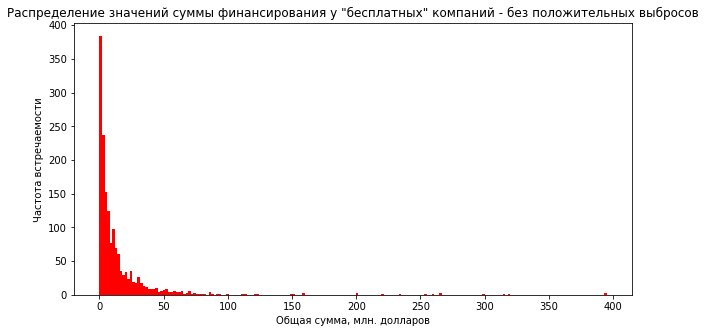

In [101]:
df_sale_nofliers = df_sale[df_sale['raised_total_mln'] < 5000]

df_sale_nofliers['raised_total_mln'].plot(kind = 'hist', color = 'red',
                                             figsize = (10,5), bins = 200)

plt.xlabel('Общая сумма, млн. долларов')
plt.ylabel('Частота встречаемости')
plt.title('Распределение значений суммы финансирования у "бесплатных" компаний - без положительных выбросов')
plt.show()

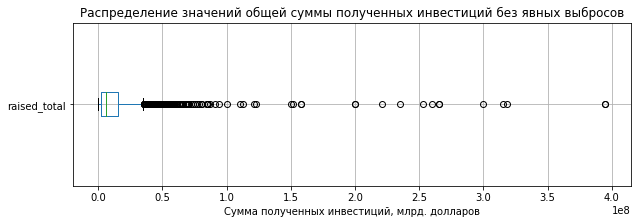

In [102]:
df_sale_nofliers.boxplot(column = 'raised_total', figsize = (10,3), vert = False)

plt.xlabel('Сумма полученных инвестиций, млрд. долларов')
plt.title('Распределение значений общей суммы полученных инвестиций без явных выбросов')
plt.show()

In [103]:
df_sale_nofliers['raised_total_mln'].describe()

count    1600.000000
mean       14.689823
std        30.213023
min         0.003750
25%         2.000000
50%         6.000000
75%        15.500000
max       395.000000
Name: raised_total_mln, dtype: float64

По результатам исследования можно составить типичный портрет компании, которая по нашим данным была продана за символическую сумму, при этом имела ненулевые инвестиции: чаще всего это компания, работающая в сфере разработки програмного обеспечения или веб разработки, базирующаяся в США. Такая компания имела от одного до трех раундов финансирования и получила в сумме от 2 до 15,5 млн. долларов.


Рассчитаем верхнюю и нижнюю границу выбросов для столбца `raised_total`:

In [104]:
# сначала найдем первый и третий квартили и межквартильный размах

q1 = total_funding_nonull['raised_total'].quantile(0.25)
q3 = total_funding_nonull['raised_total'].quantile(0.75)

iqr = q3 - q1

# для рассчета порогов для выбросов выберем коэффициент 0,02 и 1 учитывая сильную правосторонюю ассиметрию распределения
bottom = q1 - 0.02 * iqr
upper = q3 + 1*iqr

print(f'Нижний порог для выбросов значений общей суммы финансирования составляет {bottom}')
print(f'Верхний порог для выбросов значений общей суммы финансирования составляет {upper}')

Нижний порог для выбросов значений общей суммы финансирования составляет 290707.19999999995
Верхний порог для выбросов значений общей суммы финансирования составляет 21429280.0


#### Цены стартапов по категориям
Среди категорий стартапов выделим категории стартапов наиболее привлекательные для рискованных инвесторов. С характеристиками:
* типично высокими ценами;
* наибольшим разбросом цен за стартап.
  
*Объясните, почему решили составить топ именно из такого числа категорий и почему рассчитывали именно так.*

In [105]:
# посмотрим на особенности распределения цен для кампаний, которые были проданы
df_acquired = df_merged_acq[~df_merged_acq['acquired_company_id'].isna()]
df_acquired['price_amount_mlrd'] = df_acquired['price_amount'] / 1000000000

df_acquired['price_amount_mlrd'].describe()

/tmp/ipykernel_109/3755656985.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_acquired['price_amount_mlrd'] = df_acquired['price_amount'] / 1000000000


count    9327.000000
mean        0.395607
std        26.936734
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000023
max      2600.000000
Name: price_amount_mlrd, dtype: float64

Наблюдается очень большой разброс значений, для большей наглядности отфильтруем компании, которые были проданы более чем за 1000 долларов, чтобы исключить символические суммы.

In [106]:
df_acquired_nocheap = df_acquired[df_acquired['price_amount'] > 1000]
df_acquired_nocheap['price_amount_mlrd'].describe()

count    2440.000000
mean        1.512225
std        52.656804
min         0.000001
25%         0.013000
50%         0.056750
75%         0.263500
max      2600.000000
Name: price_amount_mlrd, dtype: float64

Отсеялась большая часть значений - осталось всего 2440 из 9327. Для будущей оценки разброса цен по категориям необходимо будет учитывать компании проданные дороже, чем за 1 доллар.

По результатам метода describe можно сказать, что мы имеем распределение с ярко выраженной правосторонней ассимметрией:
* Пик расположен в левой части графика: половина значений ряда принадлежит отрезку от 10 млн. долларов до 263 млн. долларов.
* Распределение имеет длинный правый хвост с положительными выбросами. Максимум составляет 2,6 трлн. долларов.
* Медиана значительно ниже среднего арифметического и для выявления типичных значений по категории следует ориентироваться именно на медиану.
* Стандартное отклонение в десятки раз превышает среднее арифметическое за счет ярко выраженных положительных выбросов.

In [107]:
# рассчитаем медиану цен для каждой категории на данных, не учитывающих продажи до 1 доллара включительно
df_acquired_nosale = df_acquired[df_acquired['price_amount'] > 1]
df_acquired_nosale['price_amount_mln'] = df_acquired_nosale['price_amount'] / 1000000

medianprice_by_cat_ser = df_acquired_nosale.groupby('category_code').agg({'price_amount_mln':['median','min','max'],
                                                                          'company_id':'count'})
medianprice_by_cat = medianprice_by_cat_ser.reset_index()
medianprice_by_cat = medianprice_by_cat.rename(columns = {'company_id':'companies_saled'})
#medianprice_by_cat = medianprice_by_cat.sort_values(by = 'median', ascending = False)

medianprice_by_cat

/tmp/ipykernel_109/2344050552.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_acquired_nosale['price_amount_mln'] = df_acquired_nosale['price_amount'] / 1000000


category_code price_amount_mln                            \
                               median         min           max   
0        advertising          60.0000    0.010000  3.100000e+03   
1          analytics         200.0000   80.000000  2.630000e+02   
2         automotive        2400.0000   43.000000  5.200000e+03   
3            biotech         200.0000    0.109000  2.000000e+04   
4          cleantech         177.5000    0.450000  3.750000e+03   
5         consulting          32.1500    0.400000  5.750000e+03   
6          ecommerce         135.0000    0.000011  1.250000e+03   
7          education          16.2500    0.200000  7.210000e+02   
8         enterprise          54.7500    0.020000  2.600000e+06   
9            fashion         195.0000   97.500000  2.700000e+02   
10           finance         170.0000    1.200000  4.400000e+03   
11       games_video          50.0000    0.000060  1.000000e+04   
12          hardware          76.0000    0.000049  4.600000e+03   
13            health         140.0000    2.500000  5.400000e+03   
14       hospitality          57.5000   10.000000  2.170000e+03   
15             local          16.1402   16.140200  1.614020e+01   
16     manufacturing         351.0000    0.000373  4.050000e+03   
17           medical         165.0000   21.500000  3.250000e+02   
18         messaging         100.0000    2.000000  1.690000e+02   
19            mobile          56.0000    0.005000  1.250000e+04   
20             music           4.8600    1.000000  2.800000e+02   
21          nanotech         584.0000  584.000000  5.840000e+02   
22   network_hosting         102.5000    0.010000  3.000000e+03   
23              news          40.0000    0.500000  3.150000e+02   
24             other          73.1000    0.002500  1.840000e+04   
25       photo_video          50.0000   36.500000  1.010470e+03   
26  public_relations         105.0000    0.025000  3.900000e+04   
27       real_estate         400.0000    3.000000  6.850000e+03   
28            search          81.2500    0.050000  1.200000e+03   
29          security         160.0000    1.850000  7.680000e+03   
30     semiconductor         100.4150    1.500000  6.500000e+03   
31            social          45.7500   10.000000  1.510000e+02   
32          software          48.0700    0.001858  1.020000e+04   
33            sports         622.5000  260.000000  9.850000e+02   
34    transportation         230.0000   20.000000  1.100000e+03   
35            travel          62.5000    2.000000  1.980000e+02   
36               web          56.0000    0.005000  6.400000e+03   

   companies_saled  
             count  
0               82  
1                3  
2                3  
3              262  
4               38  
5               32  
6               49  
7                6  
8              116  
9                3  
10              19  
11              85  
12              78  
13              10  
14               7  
15               1  
16              21  
17               4  
18               5  
19             117  
20               3  
21               1  
22              64  
23               9  
24              83  
25               5  
26              73  
27               6  
28              18  
29              35  
30              70  
31               4  
32             402  
33               2  
34               3  
35               4  
36             257

In [108]:
# посчитаем топ по медианной стоимости без учета категорий, в которых было менее 15 продаж, 
# т.к. показатели такой маленькой выборки слишком подвержены влиянию выбросов 
top_medianprice_by_cat = medianprice_by_cat[medianprice_by_cat['companies_saled']['count'] > 15]
top_medianprice_by_cat

category_code price_amount_mln                      companies_saled
                               median       min        max           count
0        advertising           60.000  0.010000     3100.0              82
3            biotech          200.000  0.109000    20000.0             262
4          cleantech          177.500  0.450000     3750.0              38
5         consulting           32.150  0.400000     5750.0              32
6          ecommerce          135.000  0.000011     1250.0              49
8         enterprise           54.750  0.020000  2600000.0             116
10           finance          170.000  1.200000     4400.0              19
11       games_video           50.000  0.000060    10000.0              85
12          hardware           76.000  0.000049     4600.0              78
16     manufacturing          351.000  0.000373     4050.0              21
19            mobile           56.000  0.005000    12500.0             117
22   network_hosting          102.500  0.010000     3000.0              64
24             other           73.100  0.002500    18400.0              83
26  public_relations          105.000  0.025000    39000.0              73
28            search           81.250  0.050000     1200.0              18
29          security          160.000  1.850000     7680.0              35
30     semiconductor          100.415  1.500000     6500.0              70
32          software           48.070  0.001858    10200.0             402
36               web           56.000  0.005000     6400.0             257

Выберем те категории, у которых медианная стоимость больше 100 млн. долларов и рассмотрим разброс цен для них

In [109]:
median_100 = top_medianprice_by_cat[top_medianprice_by_cat['price_amount_mln']['median'] >= 100]
# рассчитаем размах значений для оставшегося топа категорий
median_100['deviation_mln'] = median_100['price_amount_mln']['max'] - median_100['price_amount_mln']['min'] 
median_100 = median_100.sort_values(('price_amount_mln','median'), ascending = False)
median_100

/tmp/ipykernel_109/1982333815.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  median_100['deviation_mln'] = median_100['price_amount_mln']['max'] - median_100['price_amount_mln']['min']


category_code price_amount_mln                    companies_saled  \
                               median       min      max           count   
16     manufacturing          351.000  0.000373   4050.0              21   
3            biotech          200.000  0.109000  20000.0             262   
4          cleantech          177.500  0.450000   3750.0              38   
10           finance          170.000  1.200000   4400.0              19   
29          security          160.000  1.850000   7680.0              35   
6          ecommerce          135.000  0.000011   1250.0              49   
26  public_relations          105.000  0.025000  39000.0              73   
22   network_hosting          102.500  0.010000   3000.0              64   
30     semiconductor          100.415  1.500000   6500.0              70   

   deviation_mln  
                  
16   4049.999627  
3   19999.891000  
4    3749.550000  
10   4398.800000  
29   7678.150000  
6    1249.999989  
26  38999.975000  
22   2999.990000  
30   6498.500000

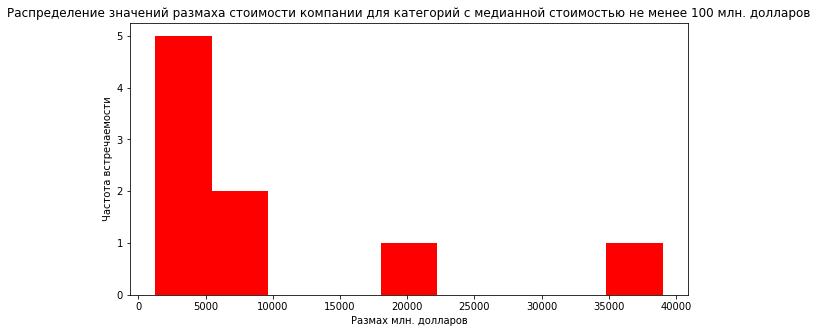

In [110]:
# оценим распределение значений размаха, чтобы выделить категории с наибольшей разницей в стоимостях 
median_100['deviation_mln'].plot(kind = 'hist', color = 'red',
                                             figsize = (10,5), bins = 9)

plt.xlabel('Размах млн. долларов')
plt.ylabel('Частота встречаемости')
plt.title('Распределение значений размаха стоимости компании для категорий с медианной стоимостью не менее 100 млн. долларов')
plt.show()

Границей отсечки можно считать размах в 5 млрд долларов. Отифильтруем категории, у которых размах больше, в итоге получим список категорий, соответствующих критериям:
1. Медианная стоимость компании более 100 млн. долларов.
2. По нашим данным продано не менее 15 компаний этой категории.
3. Размах значений стоимости в категории составляет не менее 5 млрд. долларов.


In [111]:
recommended_categories = median_100[median_100['deviation_mln'] > 5000]
recommended_categories

category_code price_amount_mln                 companies_saled  \
                               median    min      max           count   
3            biotech          200.000  0.109  20000.0             262   
29          security          160.000  1.850   7680.0              35   
26  public_relations          105.000  0.025  39000.0              73   
30     semiconductor          100.415  1.500   6500.0              70   

   deviation_mln  
                  
3      19999.891  
29      7678.150  
26     38999.975  
30      6498.500

Мы получили четыре категории кампании максимально подходящих для покупки в рамках стратегии рискованных инвестиций:
* Биотехнологии
* Безопасность
* Связи с общественностью
* Производство полупроводников

#### Сколько раундов продержится стартап перед покупкой
* Необходимо проанализировать столбец funding_rounds. Исследуйте значения столбца. Заказчика интересует типичное значение количества раундов для каждого возможного статуса стартапа.
* Постройте график, который отображает, сколько в среднем раундов финансирования проходило для стартапов из каждой группы. Сделайте выводы.


In [112]:
# сгруппируем данные по статусам
rounds_by_statuses_ser = df_companies_unique.groupby('status')['funding_rounds'].mean()
rounds_by_statuses_ser = rounds_by_statuses_ser.sort_values()
rounds_by_statuses_ser

status
operating    0.237179
acquired     0.521273
ipo          1.081923
closed       1.118058
Name: funding_rounds, dtype: float64

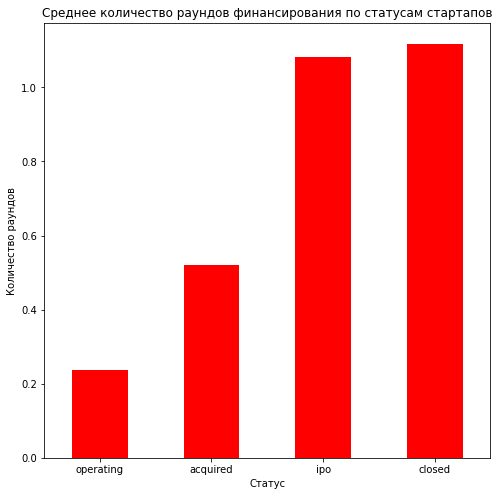

In [113]:
rounds_by_statuses_ser.plot(kind = 'bar', color = 'red',
                        figsize = (8,8), xlabel = 'Статус',
                        ylabel = 'Количество раундов', rot = 0)

plt.title('Среднее количество раундов финансирования по статусам стартапов')
plt.show()

                   

Выделяем четыре возможных статуса компании, расположим их в наиболее частом хранологическом порядке:

1. `operating` - развитие
2. `acquired` - куплена
3. `ipo` - первичное публичное предложение
4. `closed` - закрыта

Как мы видим по среднему количеству раундов финансирования для каждого статуса, такая очередность подтверждается. В среднем до покупки компания получает 0,5 раунда финансирования, такое положение связано с большим количеством компаний, у которых по нашим данным не было ни одного раунда финансирования.

Посмотрим, как изменятся показатели, если учитывать только компании, которые получили не менее одного раунда финансирования:

In [114]:
no_null_rounds = df_companies_unique[df_companies_unique['funding_rounds'] >= 1]

display(f'Всего {round(100 - no_null_rounds.shape[0] / df_companies_unique.shape[0] * 100,2)} % кампаний по нашим данным получили 0 раундов финансирования')

'Всего 83.87 % кампаний по нашим данным получили 0 раундов финансирования'

In [115]:
no_null_rounds = df_companies_unique[df_companies_unique['funding_rounds'] >= 1]

no_null_rounds_by_statuses = no_null_rounds.groupby('status')['funding_rounds'].mean()
no_null_rounds_by_statuses = no_null_rounds_by_statuses.sort_values()
no_null_rounds_by_statuses



status
closed       1.383469
operating    1.639349
acquired     1.894081
ipo          2.515528
Name: funding_rounds, dtype: float64

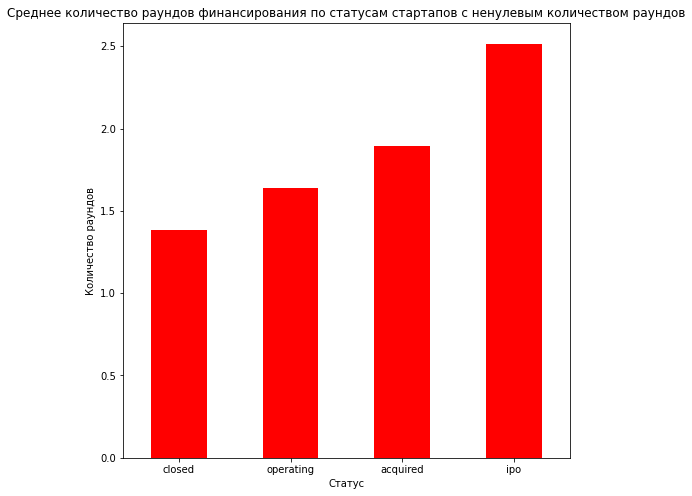

In [116]:
no_null_rounds_by_statuses.plot(kind = 'bar', color = 'red',
                        figsize = (8,8), xlabel = 'Статус',
                        ylabel = 'Количество раундов', rot = 0)

plt.title('Среднее количество раундов финансирования по статусам стартапов с ненулевым количеством раундов')
plt.show()


Для стартапов с ненулевым количеством раундов финансирования видим другую картину: закрытые компании имеют в среднем меьше всех раундов финансирования. Такое соотношение может быть связано с тем, что у остальных статусов значительно больше компаний с нулевым количеством раундов финансирования, это вызвано тем, что в статусе operating больше компаний открытых относительно недавно, поэтому получивших 0 раундов финансирования по нашим данным. Можем проверить эту гипотезу:

/tmp/ipykernel_109/3302804143.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_companies_unique_with_year['foundation_year'] = df_companies_unique_with_year['founded_at'].dt.year


<AxesSubplot:title={'center':'Динамика создания компаний, находящихся в определенном статусе на момент сбора данных'}, xlabel='foundation_year'>

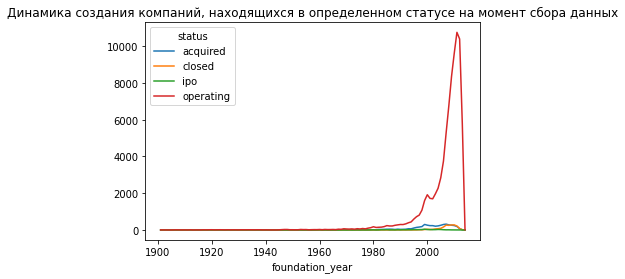

In [117]:
df_companies_unique_with_year = df_companies_unique
df_companies_unique_with_year['foundation_year'] = df_companies_unique_with_year['founded_at'].dt.year

companies_per_year = df_companies_unique_with_year.groupby(['foundation_year','status'])['company_id'].count().unstack(fill_value = 0)

companies_per_year.plot.line(title = 'Динамика создания компаний, находящихся в определенном статусе на момент сбора данных')

Видим, что в 2012-2013 годах было создано множество компаний, которые могли не успеть получить ни одного раунда финансирования на момент сбора рассматриваемых данных. В итоге можно заключить, что на момент покупки компании стартап в среднем уже получил 1,9 - почти 2 раунда финансирования.
Для развивающихся кампаний среднее количество раундов финансирования 1,6, а компании создавшие первичное публичное предложение имеют самое большое среднее количество раундов финансирования - 2,5. Уже закрытые компании в среднем получили 1,4 раунда финансирования, скорее всего это связано с тем, что они демонстрировали худшие показатели, из-за чего и были закрыты.

### Выводы и рекомендации
#### Проделанная работа
1. Проведен анализ динамики количества раундов и медианной суммы одного раунда, выявлены тенденции:
   * Типичный размер собранных в рамках одного раунда средств был максимален в 2005 году и составлял 5 500 000
   * В 2013 году наблюдается тенденция к значительному увеличению количества раундов финансирования в год - всего 11702 раунда финансирования за год. Это больше, чем за всю историю наблюдений по имеющимся данным. При этом медианная сумма одного раунда финансирования на 20% больше цифр 2012 году и остается на уровне 2011 - 1 200 000.
   * По 2013 году: в конце 2013 года в декабре наблюдается явная тенденция к увеличению медианной суммы одного раунда при значительном уменьшении количества раундов в месяц. Скорее всего имеем дело с положительными выбросами по сумме при общем уменьшении количества раундов финансирования. До декабря в течении всего года наблюдается небольшой прирост медианной суммы от месяца к месяцу с незначительным отклонением от тенденции в августе. Количество раундов финансирования колеблется в пределах от 750 до 1100 раундов в месяц, показывает рост от февраля к октябрю и резкий спад начиная с ноября.
2. Проведен анализ полноты данных об образовании сотрудников:
   * Подавляющее большинство компании имеют информацию только об одном сотруднике. Самая крупная компания по нашим данным имеет 244 сотрудника.
   * Доля сотрудников с доступной информацией об образовании значительно выше в крупных кампаниях (31-244 сотрудника), можно предположить, что это связано с налаженными бизнес-процессами, когда в штате есть специалист, собирающий данные о сотрудниках. Однако для формирования более обоснованной гипотезы необходимо уточнить, каким образом были собраны данные об образовании.
   * При необходимости можем присоединить датасет с данными о типе образования (degrees) к объединенному датасету о сотрудниках и их образовании, однако с учетом пропусков это будет малоэффективно.
3. Исследована возможность использования столбца `network_username` - он содержит разную информацию в разных таблицах и не может быть использован для присоединения.
4. Подробно оценен датасет company_and_rounds:

   * Датасет образован из двух исходных датасетов: rounds и company объединенных методом outer.
   * В исходном датасете company найдено и удалено 710 неявных дубликатов. Проверены столбцы `funding_rounds`, `investment_rounds`, `funding_total`. `funding_rounds` соответствует данным из таблицы rounds, а `investment_rounds`, `funding_total` имеют расхождения с таблицей rounds и не могут участвовать в дальнейшем исследовании.
   * Датасет разделен на два:
     - `df_companies_unique`: 195537 строк, 12 столбцов. Содержит информацию об уникальных компаниях.
     - `df_rounds`: 52928 строк, 10 столбцов. Содержит информацию о раундах финансирования и столбец `company_id`, подходящий для объединения с датасетом `df_companies_unique`.

5. Проведен исследовательский анализ объединенных таблиц:

   5.1. **Объединение данных**. В результате объединения датасетов `companies_unique` и `df_acq_types` получен датасет с информацией о компаниях, которые были проданы и / или получали инвестиции. Всего 38300 строк. Для объединения использован столбец `company_id`.
   
   5.2. **Анализ выбросов в данных об общей сумме финансирования**. Распределение ассиметричное с длинным правым хвостом, половина значений сконцентрированы на отрезке от 500. тыс долларов до 11 млн долларов - такие размеры общего финансирования для одной кампании считаем типичным. Разброс значений очень велик, что объясняется большим разнообразием представленных компаний. Это может давать искажения при использовании традиционных методов оценки: мер центральной тенденции и стандартного отклонения, необходимо учитывать эту особенность. В будущем будет более эффективно категоризировать компании по различным признакам для поиска тенденций в показателе общей суммы инвестиций.
   
   5.3. **Бесплатные компании**. Исследованы компании, проданные за 1 и 0 долларов и имевшие ненулевую сумму инвестиций. По результатам исследования можно составлен типичный портрет такой компании: чаще всего это компания, работающая в сфере разработки програмного обеспечения или веб разработки, базирующаяся в США. Такая компания имела от одного до трех раундов финансирования и получила в сумме от 2 до 15,5 млн. долларов.
   
   5.4. **Цены стартапов по категориям**. Исследованы цены в разрезе категорий, рассмотрены меры центральной тенденции и размах значений с учетом количества проданных компаний в категории. По итогам исследования получены четыре категории кампании максимально подходящих для покупки в рамках стратегии рискованных инвестиций:
* Биотехнологии
* Безопасность
* Связи с общественностью
* Производство полупроводников
  
   5.5. **Количество раундов финансирования**. 83% компаний не получили ни одного раунда финансирования, здесь мы рассматривали те стартапы, которые получили хотя бы один раунд. Выявлено, что на момент покупки компании стартап в среднем уже получил **1,9** - почти 2 раунда финансирования.
Для развивающихся кампаний среднее количество раундов финансирования **1,6**, а компании, создавшие первичное публичное предложение, имеют самое большое среднее количество раундов финансирования - **2,5**. Уже закрытые компании в среднем получили **1,4** раунда финансирования, скорее всего это связано с тем, что они демонстрировали худшие показатели, из-за чего и были закрыты.

#### Оценка качества данных
* Распределение значений: большиство непрерывных переменных в имеющихся данных (наприме, общая стоимость инвестиций и стоимость компаний) имеют очень большой разброс значений. Необходимо максимально конкретно сформулировать цели исследования, чтобы у аналитика была возможность ввести соответствующую категоризацию компаний, и рассматривать особенности распределения этих переменных внутри категорий, сравнивать между категориями.
* Количество пропусков: данные имеют множество пропусков, если есть возможность устранить их с помощью парсинга - это значительно повысит качество последующих исследований. 

#### Рекомендации
По итогам исследования рекомендуем рассмотреть для покупки в рамках стратегии рискованных инвестиций компании из четырех категорий:
* Биотехнологии
* Безопасность
* Связи с общественностью
* Производство полупроводников